# SpaceX S-1 — Connectivity (Starlink) segment economics

An open analysis of the Connectivity (Starlink) segment from SpaceX's Form S-1, for readers who know
technology but not necessarily finance. Finance terms are defined inline; the engineering is assumed.

**The one question this notebook answers: how much cash does Starlink actually generate?** Not accounting
profit, not EBITDA — cash, after paying to replace the hardware that physically wears out. For a business
whose assets literally burn up, that distinction is the whole story.

**Data.** Every input is a GAAP figure from the S-1 segment disclosures, loaded from `csv/` via
`analysis.data`. The full filing text is in `source_docs/spacex-s1.pdf`. The only input that is *not*
from the S-1 is SpaceX's internal marginal cost to fly one reused Falcon 9 (~\$15–20M), which the
company does not disclose.

**Method — why free cash flow is the measure that matters.**
- **Free cash flow (FCF) = cash from operations (CFO) − capex.** This is the cash left over *after* the
  business pays to build and replace its assets. It is what an owner can actually take out, and it is what
  a valuation discounts. The S-1 reports CFO only on a consolidated basis, so at the segment level we build
  a CFO proxy from fundamentals: operating income plus the non-cash charges (depreciation & amortization,
  stock-based compensation, impairment). It excludes working-capital movements, which for Starlink are a
  cash *source* (subscriptions are prepaid) — so the proxy is deliberately conservative.
- **EBITDA is shown for comparison only — never used in a calculation.** EBITDA = earnings before interest,
  taxes, depreciation, and amortization. Adding depreciation back assumes it is a paper charge that doesn't
  cost real money. For most asset-light software, that is roughly fair. For SpaceX it is not: the
  depreciation it strips out is the cost of hardware that is being consumed in front of us — Falcon boosters
  reach an end-of-life flight count and are retired, and Starlink satellites deorbit and burn up after a few
  years. That hardware has to be rebuilt with cash, year after year, just to stand still. FCF captures that
  replacement cost (through capex); EBITDA pretends it away. So EBITDA overstates what Starlink earns, and we
  use it only to show *how large* that overstatement is.
- Dollar figures are in millions USD. Periods: FY2023–FY2025 (years to Dec 31) and Q1-2026 (three
  months to Mar 31, 2026).

In [1]:
# Locate the repo root (the directory containing `analysis/`) so imports work from anywhere.
import os, sys
_p = os.getcwd()
while _p != os.path.dirname(_p) and not os.path.isdir(os.path.join(_p, "analysis")):
    _p = os.path.dirname(_p)
if _p not in sys.path:
    sys.path.insert(0, _p)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis import data, charts
from analysis.connectivity_economics import (
    ConnectivityModel, PERIODS, INTERNAL_LAUNCH_COST_M, KIT_SHARE, SAT_LIFE_SENSITIVITY_M)

charts.apply_style()
TEAL, NAVY, ORANGE = charts.SEGMENT_COLORS["Connectivity"], charts.SEGMENT_COLORS["Space"], charts.SEGMENT_COLORS["AI"]

R = ConnectivityModel().raw()      # per-period Connectivity fundamentals from the S-1 CSVs

def fmt(df, pct=(), one=()):
    """Table display helper: percent for margin cols, 1 decimal for per-launch cols, else $M integers."""
    spec = {c: ("{:.1%}" if c in pct else ("{:,.1f}" if c in one else "{:,.0f}"))
            for c in df.columns if c in pct or c in one or pd.api.types.is_numeric_dtype(df[c])}
    return df.style.format(spec)

R.T   # the raw S-1 inputs every later calculation is built from

period,FY2023,FY2024,FY2025,Q1-2026
revenue,3869.000,7599.000,11387.00,3257.000
op_income,469.000,2006.000,4423.00,1188.000
cogs,2786.000,4768.000,5921.00,1651.000
rnd,381.000,453.000,575.00,205.000
sga,233.000,333.000,468.00,213.000
restructuring,0.000,0.000,0.00,0.000
impairment,0.000,39.000,0.00,0.000
da,884.000,1508.000,2376.00,783.000
sbc,249.000,296.000,369.00,116.000
capex,2455.000,3498.000,4178.00,1332.000


## 1. Launch costs are inside the Connectivity segment

A natural question: are Starlink's launch costs buried in the Space segment, which would make
Connectivity look more profitable than it is? The S-1 answers it directly — they are **capitalized
into Connectivity and depreciated**:

> **MD&A (p. 81):** "For launches dedicated to deploying our Starlink satellites, *we capitalize the
> associated costs within our Connectivity segment and depreciate them over time*, and we do not
> recognize revenue for those launches in our Space segment."

> **PP&E note (F-14):** "Satellites include costs to build the satellites … as well as *capitalized
> launch costs incurred by the Space segment to launch the satellites to orbit, which include an
> allocation of the flight vehicle hardware costs*."

The FY2025 cost-of-revenue change is even attributed to *"higher depreciation of \$827M from
capitalized launch and satellite costs."* So reported operating income **already includes launch
cost** — as depreciation of capitalized launch spend, at SpaceX's internal cost. The same spend also
sits in capex, so the FCF below captures it too.

In [2]:
pl = pd.DataFrame(index=pd.Index(PERIODS, name="period"))
pl["Revenue"]          = R.revenue
pl["Operating income"] = R.op_income
pl["Op margin"]        = R.op_income / R.revenue
pl["D&A"]              = R.da
pl["Capex"]            = R.capex
fmt(pl, pct=["Op margin"])

,Revenue,Operating income,Op margin,D&A,Capex
period,,,,,
FY2023,"3,869",469,12.1%,884,"2,455"
FY2024,"7,599","2,006",26.4%,"1,508","3,498"
FY2025,"11,387","4,423",38.8%,"2,376","4,178"
Q1-2026,"3,257","1,188",36.5%,783,"1,332"


## 2. Where the cost of revenue goes ($5,921M, FY2025)

The S-1 lists the cost-of-revenue components (p. 100) — *"depreciation (inclusive of launch, satellite,
and ground infrastructure costs), Starlink Kit costs, shipping and handling, ground operating expenses,
employee compensation … payment processor fees, warranty … customs and duties"* — but not their dollar
amounts. We anchor the one disclosed (depreciation = segment D&A) and treat the rest as a residual
"cash COGS". The split of that residual into hardware vs. network is **illustrative** (not disclosed);
Starlink Kits are sold near cost, so they are roughly pass-through.

,FY2025 ($M)
Cost of revenue,5921.0
Depreciation (launch+sat+ground),2376.0
Cash COGS (everything else),3545.0
~ Starlink Kit hardware (est.),1418.0
~ Network ops/support/fees (est.),2127.0


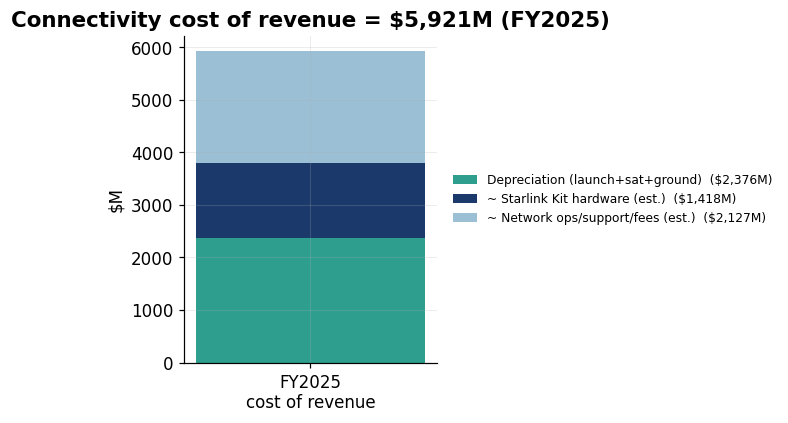

In [3]:
cogs25, da25 = R.cogs["FY2025"], R.da["FY2025"]
cash_cogs = cogs25 - da25
kit       = cash_cogs * KIT_SHARE

cd = pd.Series({
    "Cost of revenue":                    cogs25,
    "Depreciation (launch+sat+ground)":   da25,
    "Cash COGS (everything else)":        cash_cogs,
    "~ Starlink Kit hardware (est.)":     kit,
    "~ Network ops/support/fees (est.)":  cash_cogs - kit,
}, name="FY2025 ($M)")
display(cd.round(0).to_frame())

parts = cd[["Depreciation (launch+sat+ground)", "~ Starlink Kit hardware (est.)", "~ Network ops/support/fees (est.)"]]
fig, ax = plt.subplots(figsize=(6.5, 4)); bottom = 0
for (label, val), c in zip(parts.items(), [TEAL, NAVY, "#9bbfd4"]):
    ax.bar("FY2025\ncost of revenue", val, bottom=bottom, color=c, label=f"{label}  (${val:,.0f}M)")
    bottom += val
ax.set_title("Connectivity cost of revenue = $5,921M (FY2025)")
ax.set_ylabel("$M"); ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
charts.finish(fig); charts.save(fig, "connectivity_cogs", layout=False); plt.show()

About **40% of cost of revenue is depreciation of the constellation** (launch + satellite + ground), and
it is the fastest-growing component (+\$827M year over year). This is the single most important fact about
Starlink's cost structure: the dominant cost is not bandwidth, support, or hardware shipped to customers —
it is the **steady write-down of a satellite fleet that is physically being used up.** Starlink satellites
operate for only a few years before atmospheric drag pulls them down to burn up on reentry, so the fleet
must be continuously rebuilt and relaunched just to keep service running. Depreciation is the accounting
shadow of that physical reality, and the S-1 quantifies how sharp it is: a ±1-year change in assumed
satellite useful life moves FY2025 operating income by about **\$480M**. Because this cost is large, real,
and recurring, any measure that adds it back — EBITDA — describes a business that does not exist. That is
the subject of the next section.

## 3. Cash flow, not EBITDA

This is the heart of the analysis. To value Starlink we need the cash it actually throws off after keeping
its constellation alive — not a profit figure that ignores the cost of replacing satellites that fall out
of the sky.

**FCF = CFO − capex.** We build the segment CFO proxy from fundamentals (operating income + the non-cash
charges), then subtract capex — the cash spent building and replacing satellites, ground stations, and
launch hardware. What survives that subtraction is real free cash flow.

In [4]:
ff = pd.DataFrame(index=pd.Index(PERIODS, name="period"))
ff["Operating income"]              = R.op_income
ff["+ D&A (non-cash)"]              = R.da
ff["+ SBC (non-cash)"]             = R.sbc
ff["+ Impairment (non-cash)"]      = R.impairment
ff["= CFO (proxy, excl. ΔWC)"]     = R.op_income + R.da + R.sbc + R.impairment
ff["− Capex"]                      = -R.capex
ff["= FCF"]                        = (R.op_income + R.da + R.sbc + R.impairment) - R.capex
ff["FCF margin"]                   = ff["= FCF"] / R.revenue
ff["Maintenance capex (≈ D&A)"]    = R.da
ff["Growth capex (capex − D&A)"]   = R.capex - R.da
fmt(ff, pct=["FCF margin"])

,Operating income,+ D&A (non-cash),+ SBC (non-cash),+ Impairment (non-cash),"= CFO (proxy, excl. ΔWC)",− Capex,= FCF,FCF margin,Maintenance capex (≈ D&A),Growth capex (capex − D&A)
period,,,,,,,,,,
FY2023,469,884,249,0,"1,602","-2,455",-853,-22.0%,884,"1,571"
FY2024,"2,006","1,508",296,39,"3,849","-3,498",351,4.6%,"1,508","1,990"
FY2025,"4,423","2,376",369,0,"7,168","-4,178","2,990",26.3%,"2,376","1,802"
Q1-2026,"1,188",783,116,0,"2,087","-1,332",755,23.2%,783,549


These segment building blocks tie out to the consolidated cash-flow statement — a check that the
proxy is on the right basis (the three segments' D&A, SBC, and capex each sum to the consolidated
FY2025 lines):

In [5]:
sup, cf = data.load("segment_supplemental"), data.load("cash_flow")
checks = [("Depreciation and amortization", "Depreciation and amortization"),
          ("Share-based compensation",      "Share-based compensation"),
          ("Capital expenditures",          "Purchases of property plant and equipment")]
rows = {}
for seg_metric, cf_item in checks:
    seg_sum = sup[(sup.metric == seg_metric) & (sup.period == "FY2025")]["value"].sum()
    cons    = abs(cf[(cf.line_item == cf_item) & (cf.period == "FY2025")]["value"].iloc[0])
    rows[seg_metric] = {"segments summed": seg_sum, "consolidated cash flow": cons, "match": seg_sum == cons}
pd.DataFrame(rows).T

,segments summed,consolidated cash flow,match
Depreciation and amortization,6701,6701,True
Share-based compensation,1947,1947,True
Capital expenditures,20737,20737,True


### Why EBITDA is misleading here (shown for comparison only)
EBITDA adds depreciation back to profit, on the theory that depreciation is a bookkeeping entry rather than
a cash cost. **For SpaceX that theory is false.** The depreciation being added back is the using-up of real
hardware: Falcon boosters hit an end-of-life flight count and are retired, and Starlink satellites deorbit
and burn up after a few years. None of it can be reused — it must be physically rebuilt and reflown, with
cash, every year. That replacement spending is exactly what shows up in capex, which EBITDA conveniently
leaves out. So EBITDA describes a fictional Starlink that never has to replace anything. FCF — profit plus
non-cash charges, *minus* the capex that funds replacement — describes the real one. The table and chart
below show how far apart the two are.

In [6]:
cmp = pd.DataFrame(index=pd.Index(PERIODS, name="period"))
cmp["GAAP EBITDA (op income + D&A)"]            = R.op_income + R.da
cmp["Adj. EBITDA (S-1: +SBC +restr +impair)"]   = R.adj_ebitda_reported   # comparison only
cmp["FCF (CFO − capex)"]                         = (R.op_income + R.da + R.sbc + R.impairment) - R.capex
cmp["EBITDA − FCF (asset-replacement cash)"]    = (R.op_income + R.da) - cmp["FCF (CFO − capex)"]
fmt(cmp)

,GAAP EBITDA (op income + D&A),Adj. EBITDA (S-1: +SBC +restr +impair),FCF (CFO − capex),EBITDA − FCF (asset-replacement cash)
period,,,,
FY2023,"1,353","1,602",-853,"2,206"
FY2024,"3,514","3,849",351,"3,163"
FY2025,"6,799","7,168","2,990","3,809"
Q1-2026,"1,971","2,087",755,"1,216"


### Charting a full year: the FY2026E estimate

We have only one quarter of fiscal 2026 (Q1, to Mar 31). Dropping that three-month stub next to full
years would make every chart look like the business fell off a cliff, so for the time-series charts we
replace it with a full-year estimate, **FY2026E**, built straight from the quarter in hand: grow each
FY2025 line item by its own **Q1-2026-over-Q1-2025 growth rate**. This is a mechanical run-rate
extrapolation — *if the year-over-year pace set in Q1 holds, where does the full year land?* — not a
bottom-up forecast. FY2026E is drawn **hatched** in every chart to flag it as an estimate; the tables
above keep the actual reported quarter.

The estimate carries a signal worth reading before the chart: revenue grows ~32% and EBITDA keeps
climbing, but **capex is accelerating faster (+64% YoY) than operating income (+15%)**, so projected FCF
holds roughly flat instead of rising. That is reinvestment, not deterioration — SpaceX is plowing the
quarter's extra cash straight back into expanding the fleet.

In [7]:
# FY2026E — annualize the partial Q1-2026 quarter so the charts compare like with like.
# Method: grow each FY2025 line item by its own Q1-2026 / Q1-2025 (year-over-year) rate.
Q     = ConnectivityModel().raw(["Q1-2025", "Q1-2026"])   # both first quarters, same columns as R
yoy   = Q.loc["Q1-2026"] / Q.loc["Q1-2025"]               # per-line year-over-year growth
fy26e = R.loc["FY2025"] * yoy
fy26e["impairment"] = 0.0; fy26e["restructuring"] = 0.0   # none assumed in the estimate

CHART_PERIODS = ["FY2023", "FY2024", "FY2025", "FY2026E"]
def to_chart(series, est):
    """Three reported full years (from an R column) + the FY2026E estimate."""
    return list(series.loc[["FY2023", "FY2024", "FY2025"]]) + [est]

keys = ["revenue", "op_income", "da", "sbc", "capex"]
est  = pd.DataFrame({"FY2025 (actual)": R.loc["FY2025", keys],
                     "Q1 YoY growth":   yoy[keys] - 1,
                     "FY2026E (est.)":  fy26e[keys]})
fmt(est, pct=["Q1 YoY growth"])

,FY2025 (actual),Q1 YoY growth,FY2026E (est.)
revenue,"11,387",31.6%,"14,985"
op_income,"4,423",15.0%,"5,087"
da,"2,376",53.5%,"3,648"
sbc,369,54.7%,571
capex,"4,178",63.6%,"6,837"


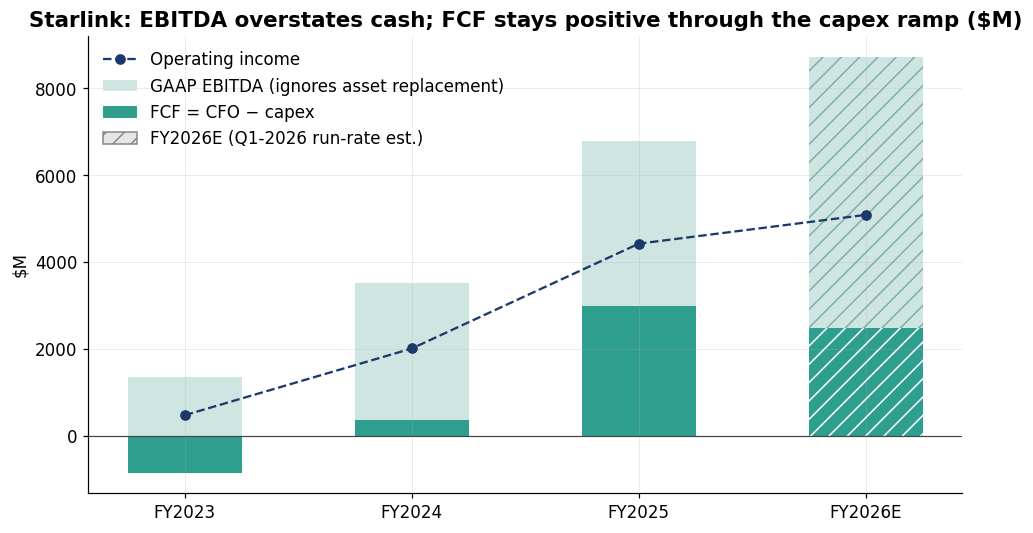

In [8]:
from matplotlib.patches import Patch
fig, ax = plt.subplots()
ebitda = to_chart(R.op_income + R.da,
                  fy26e["op_income"] + fy26e["da"])
fcf    = to_chart((R.op_income + R.da + R.sbc + R.impairment) - R.capex,
                  fy26e["op_income"] + fy26e["da"] + fy26e["sbc"] + fy26e["impairment"] - fy26e["capex"])
opinc  = to_chart(R.op_income, fy26e["op_income"])
x = np.arange(len(CHART_PERIODS))

b_eb = ax.bar(x, ebitda, width=0.5, color="#cfe5e1", label="GAAP EBITDA (ignores asset replacement)")
b_fc = ax.bar(x, fcf,    width=0.5, color=TEAL,      label="FCF = CFO − capex")
ax.plot(x, opinc, "o--", color=NAVY, label="Operating income")
for bars, hatch_c in ((b_eb, "#7fb0a8"), (b_fc, "white")):   # hatch the FY2026E (last) bar = estimate
    bars[-1].set_hatch("//"); bars[-1].set_edgecolor(hatch_c); bars[-1].set_linewidth(0)
ax.axhline(0, color="#444", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(CHART_PERIODS)
ax.set_title("Starlink: EBITDA overstates cash; FCF stays positive through the capex ramp ($M)")
ax.set_ylabel("$M")
handles, _ = ax.get_legend_handles_labels()
handles.append(Patch(facecolor="0.9", edgecolor="#888", hatch="//", label="FY2026E (Q1-2026 run-rate est.)"))
ax.legend(handles=handles)
charts.finish(fig); charts.save(fig, "connectivity_fcf", layout=False); plt.show()

In FY2025 GAAP EBITDA was ~\$6.8B, but **real free cash flow was ~\$3.0B** — EBITDA overstates cash
generation by roughly **2×**. The ~\$3.8B gap is not an accounting artifact; it is the cash SpaceX spent
replacing and growing hardware that the EBITDA figure simply ignores. Anyone valuing Starlink off EBITDA is
valuing a company that gets to keep its satellites for free.

The honest figure, FCF, traces a clean infrastructure **J-curve**: −\$0.9B (2023) → +\$0.4B (2024) →
+\$3.0B (2025). Early years are cash-negative because the fleet is being built ahead of the revenue; once
the base is in place, each incremental subscriber drops far more cash to the bottom line. On the Q1-2026
run-rate (the hatched **FY2026E** bar), FCF holds near ~\$2.5B even as revenue grows ~32% — capex is
ramping faster than profit, so the gains are being reinvested into fleet expansion rather than released as
free cash flow. That is a choice, not a ceiling: it is the next point that determines value.

**Maintenance vs. growth capex.** Not all of that capex is replacement. Holding the constellation steady —
replacing satellites as they deorbit — costs roughly the depreciation amount, ≈\$2,376M in FY2025; the
remaining ~\$1.8B is *growth* capex, expanding the fleet and coverage. This split is what makes the
business look better over time: as subscriber growth matures and growth capex tapers toward bare
maintenance, FCF rises toward the high-30s% of revenue (its operating-margin territory). Two honest
caveats: stock-based compensation is added back as non-cash but is a real dilution cost (~\$369M in
FY2025), and the proxy excludes prepaid-subscription working capital, which would *raise* CFO — i.e., the
real number is, if anything, a little better than shown.

## 4. The launch-cost moat: an internal vs. market price gap

Connectivity is charged for launch at SpaceX's **internal marginal cost** (~\$15–20M per reused
Falcon 9). An independent operator would pay the **customer price**, derived from the S-1's own
customer launch economics:

$$\text{market price per launch} = \frac{\text{Space revenue} \times \text{Launch-Services share}}{\text{customer launches}}$$

Internal Starlink launch counts are S-1 actuals (footnote, p. 87): 63 → 89 → 122 over 2023–2025. The
quarterly market price is noisy (small customer-launch denominator); the full-year figures (~\$58–60M)
are the reliable reference. The chart's **FY2026E** bar applies that ~\$60M reference to the projected
~168 Starlink launches (FY2025 launches grown at the Q1 year-over-year rate).

In [9]:
market_price = R.space_revenue * R.ls_pct / R.customer_launches   # S-1-implied $/launch
spread       = market_price - INTERNAL_LAUNCH_COST_M

le = pd.DataFrame(index=pd.Index(PERIODS, name="period"))
le["Starlink launches"]              = R.starlink_launches
le["Customer launches"]              = R.customer_launches
le["Market $/launch (S-1)"]          = market_price
le["Internal $/launch"]              = INTERNAL_LAUNCH_COST_M
le["Spread $/launch"]                = spread
le["Internal launch cash"]           = R.starlink_launches * INTERNAL_LAUNCH_COST_M
le["At market price"]                = R.starlink_launches * market_price
le["Vertical-integration advantage"] = le["At market price"] - le["Internal launch cash"]
le["Standalone op income"]           = R.op_income - spread * R.starlink_launches  # if launch bought at market
le["Standalone op margin"]           = le["Standalone op income"] / R.revenue
fmt(le, pct=["Standalone op margin"], one=["Market $/launch (S-1)", "Internal $/launch", "Spread $/launch"])

,Starlink launches,Customer launches,Market $/launch (S-1),Internal $/launch,Spread $/launch,Internal launch cash,At market price,Vertical-integration advantage,Standalone op income,Standalone op margin
period,,,,,,,,,,
FY2023,63,33,59.5,17.5,42.0,"1,102","3,748","2,646","-2,177",-56.3%
FY2024,89,45,57.5,17.5,40.0,"1,558","5,120","3,563","-1,557",-20.5%
FY2025,122,43,59.9,17.5,42.4,"2,135","7,303","5,168",-745,-6.5%
Q1-2026,33,7,47.1,17.5,29.6,578,"1,555",978,210,6.5%


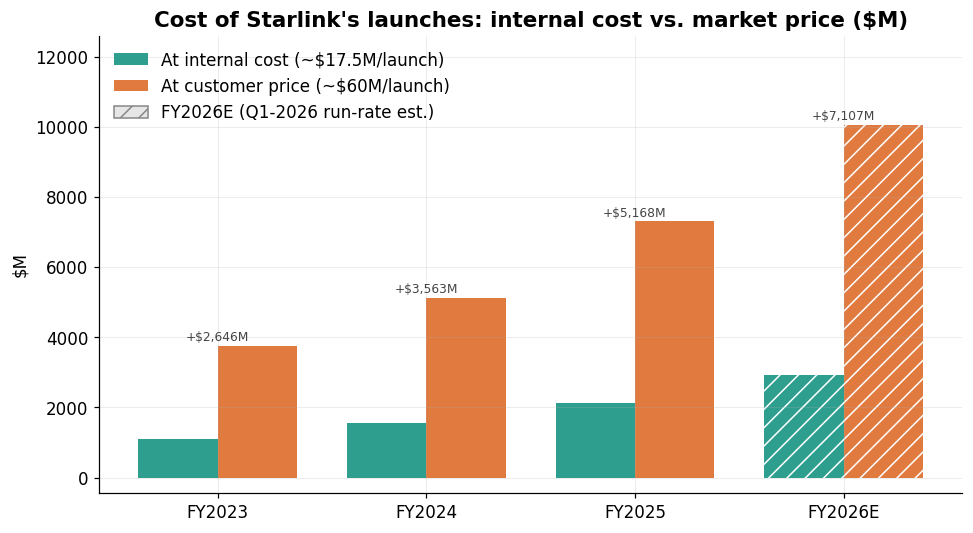

In [10]:
from matplotlib.patches import Patch
mp = R.space_revenue * R.ls_pct / R.customer_launches        # full-year market $/launch (S-1-implied)
sl = to_chart(R.starlink_launches, fy26e["starlink_launches"])
internal_cash = [s * INTERNAL_LAUNCH_COST_M for s in sl]
# FY2026E market price holds FY2025's reliable full-year ~$60M (quarterly price is too noisy to project)
at_market = to_chart(R.starlink_launches * mp, fy26e["starlink_launches"] * mp["FY2025"])
adv = [m - i for m, i in zip(at_market, internal_cash)]

x = np.arange(len(CHART_PERIODS)); w = 0.38
fig, ax = plt.subplots()
b_i = ax.bar(x - w/2, internal_cash, w, color=TEAL,   label="At internal cost (~$17.5M/launch)")
b_m = ax.bar(x + w/2, at_market,     w, color=ORANGE, label="At customer price (~$60M/launch)")
for bars in (b_i, b_m):                                       # hatch the FY2026E (last) bar = estimate
    bars[-1].set_hatch("//"); bars[-1].set_edgecolor("white"); bars[-1].set_linewidth(0)
for i in range(len(CHART_PERIODS)):
    ax.text(i, at_market[i] + 150, f"+${adv[i]:,.0f}M", ha="center", fontsize=8, color="#444")
ax.set_xticks(x); ax.set_xticklabels(CHART_PERIODS)
ax.set_ylim(top=max(at_market) * 1.12)
ax.set_title("Cost of Starlink's launches: internal cost vs. market price ($M)")
ax.set_ylabel("$M")
handles, _ = ax.get_legend_handles_labels()
handles.append(Patch(facecolor="0.9", edgecolor="#888", hatch="//", label="FY2026E (Q1-2026 run-rate est.)"))
ax.legend(handles=handles)
charts.finish(fig); charts.pad_ylim(ax)
charts.save(fig, "connectivity_launch_moat", layout=False); plt.show()

In FY2025 self-launching saved roughly **\$5.2B** versus buying launch at market (Falcon 9 reuse:
157 of 165 FY2025 flights used flight-proven boosters). Re-pricing launch at the ~\$60M customer price
turns the segment's operating profit into a small **loss** at FY2025 revenue — it only stays positive
if launch costs less than ~\$23–25M. The reported ~39% operating margin is real but depends on owning
the rockets.

In [11]:
mp25, op25, sl25, rev25 = (market_price["FY2025"], R.op_income["FY2025"],
                            R.starlink_launches["FY2025"], R.revenue["FY2025"])
sens = pd.DataFrame({"Internal $/launch": [15, 17.5, 20, 25]})
sens["Spread $/launch"]      = mp25 - sens["Internal $/launch"]
sens["Standalone op income"] = op25 - sens["Spread $/launch"] * sl25
sens["Standalone op margin"] = sens["Standalone op income"] / rev25
fmt(sens.set_index("Internal $/launch"), pct=["Standalone op margin"], one=["Spread $/launch"])

,Spread $/launch,Standalone op income,Standalone op margin
Internal $/launch,,,
15.000000,44.9,"-1,050",-9.2%
17.500000,42.4,-745,-6.5%
20.000000,39.9,-440,-3.9%
25.000000,34.9,170,1.5%


## 5. Opportunity cost of a Starlink-dedicated rocket

If every FY2025 Starlink launch could instead have been sold to a customer, the forgone amount would be
large (the ceiling below). But that assumes unlimited external demand. SpaceX flew only **43 customer
launches** versus **122** for Starlink, and the S-1 states that Starlink *backfills* otherwise-idle
launch slots:

> *"When an expected customer payload for a planned launch is not available, we instead use launch
> capacity for our satellites."*

External demand — not launch capacity — is the binding constraint, so the **realistic marginal
opportunity cost is close to zero**: Starlink monetizes capacity that would otherwise go unused. (If
future external or internal launch demand exceeds capacity, this opportunity cost would rise.)

In [12]:
oc = pd.Series({
    "Starlink launches":               sl25,
    "Customer launches":               R.customer_launches["FY2025"],
    "Ceiling: forgone revenue":        sl25 * mp25,
    "Ceiling: forgone margin":         sl25 * (mp25 - INTERNAL_LAUNCH_COST_M),
    "Realistic marginal (backfill)":   0.0,
}, name="FY2025 ($M)")
oc.round(0).to_frame()

,FY2025 ($M)
Starlink launches,122.0
Customer launches,43.0
Ceiling: forgone revenue,7303.0
Ceiling: forgone margin,5168.0
Realistic marginal (backfill),0.0


## 6. Pinning down SpaceX's internal launch cost

**Goal.** Everything in §4 hinges on one number the S-1 never prints: what it costs SpaceX *internally*
to fly one reused Falcon 9. We use **~\$15–20M**. This section asks whether that figure can be defended —
and it matters twice. Here it sets the size of Starlink's launch-cost moat; later, in the **Space segment**
section, we reuse the *same* internal cost to strip the intercompany Starlink launches out of Space and
recover that segment's true third-party profitability. One number, two valuations.

**Why a range, and why this one.** Two independent roads reach the same place:
- *External evidence.* Public estimates of the marginal cost of a flight-proven Falcon 9 cluster in the
  \$15–20M band (≈25% of the ~\$67M list price; Musk has cited a ~\$15M floor). This corroborates the
  number — it is not the source, since SpaceX does not disclose it.
- *The S-1's own books (below).* The disclosed Satellites PP&E line, launch count, and depreciation
  sensitivity, taken together, independently reproduce that **same \$15–20M band**.

When an outside estimate and the company's own accounting agree without being fit to each other, the
*range* is trustworthy even though no single point is — which is why we commit to a band and carry the
sensitivity (§4) rather than pretend to a precise figure.

The mechanic: the PP&E note puts **Satellites** at \$11,949M gross (end-2025), up **\$4,358M** in the year,
and that line fuses *satellite hardware* + *capitalized launch cost*. Split the addition by an assumed
**satellite-manufacturing share**, divide the launch portion by the year's **122** Starlink launches, and
read off the implied cost per launch. (The \$4,358M is gross and net of deorbited satellites removed from
the books, so it is a slight **floor** — true spend, and the implied per-launch cost, run a touch higher.)

In [13]:
sat_gross  = {"2024-12-31": 7591, "2025-12-31": 11949}              # PP&E note (F-14), Satellites gross, $M
sat_add25  = sat_gross["2025-12-31"] - sat_gross["2024-12-31"]      # 4,358 added in FY2025 (gross, net of retirements)
launches25 = R.starlink_launches["FY2025"]                         # 122 internal Starlink launches

shares = np.array([0.40, 0.45, 0.50, 0.55, 0.60, 0.65])            # ASSUMPTION: satellite-mfg share of capitalized cost
tri = pd.DataFrame({
    "Satellite-mfg share": shares,
    "Launch share":        1 - shares,
    "Launch capex ($M)":   (1 - shares) * sat_add25,
    "Implied $/launch":    (1 - shares) * sat_add25 / launches25,
})
display(fmt(tri, pct=["Satellite-mfg share", "Launch share"], one=["Implied $/launch"]))

implied_share = 1 - INTERNAL_LAUNCH_COST_M * launches25 / sat_add25
print(f"Satellites gross addition FY2025: ${sat_add25:,.0f}M over {launches25:.0f} internal launches")
print(f"Our ${INTERNAL_LAUNCH_COST_M:.1f}M/launch assumption  <=>  satellite-mfg share = {implied_share:.0%} "
      f"(launch and hardware roughly half-and-half)")

,Satellite-mfg share,Launch share,Launch capex ($M),Implied $/launch
0,40.0%,60.0%,"2,615",21.4
1,45.0%,55.0%,"2,397",19.6
2,50.0%,50.0%,"2,179",17.9
3,55.0%,45.0%,"1,961",16.1
4,60.0%,40.0%,"1,743",14.3
5,65.0%,35.0%,"1,525",12.5


Satellites gross addition FY2025: $4,358M over 122 internal launches
Our $17.5M/launch assumption  <=>  satellite-mfg share = 51% (launch and hardware roughly half-and-half)


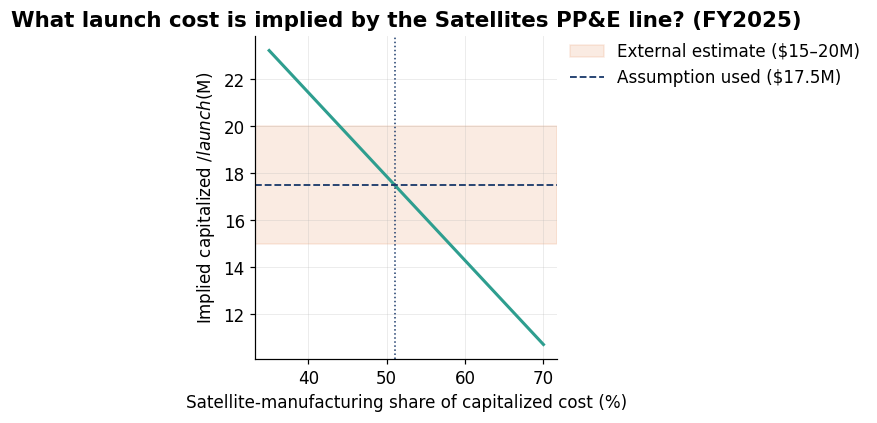

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ss = np.linspace(0.35, 0.70, 100)
ax.plot(ss * 100, (1 - ss) * sat_add25 / launches25, color=TEAL, lw=2)
ax.axhspan(15, 20, color=ORANGE, alpha=0.15, label="External estimate ($15–20M)")
ax.axhline(INTERNAL_LAUNCH_COST_M, color=NAVY, ls="--", lw=1.2,
           label=f"Assumption used (${INTERNAL_LAUNCH_COST_M:.1f}M)")
ax.axvline(implied_share * 100, color=NAVY, ls=":", lw=1)
ax.set_xlabel("Satellite-manufacturing share of capitalized cost (%)")
ax.set_ylabel("Implied capitalized $/launch ($M)")
ax.set_title("What launch cost is implied by the Satellites PP&E line? (FY2025)")
charts.legend_outside(ax)
charts.save(fig, "connectivity_launch_cost_triangulation"); plt.show()

The table reads two ways. **Forward:** pick a satellite-manufacturing share, get a per-launch cost — a
**44–58%** share spans the whole \$15–20M band, and **~50%** (hardware and launch roughly equal) lands on
the \$17.5M we use. **Backward:** our \$17.5M assumption is *equivalent to* assuming the spacecraft is ~51%
of capitalized cost. Either way the figure is anchored to a disclosed number, not invented.

**Cross-check: the depreciation period.** That split is only credible if the implied *life* over which the
cost is depreciated matches reality. The S-1 gives the lever — a ±1-year change in satellite useful life
moves FY2025 operating income ~\$480M (§2). Under straight-line depreciation, annual depreciation = base / L,
so a one-year change is base / [L(L+1)]; setting that equal to \$480M pins the life:

In [15]:
sens     = SAT_LIFE_SENSITIVITY_M["FY2025"]                          # 480  ($M op income per ±1 yr)
avg_base = (sat_gross["2024-12-31"] + sat_gross["2025-12-31"]) / 2   # ~9,770 (avg Satellites gross)

def implied_life(base):                                              # solve base / [L(L+1)] = sens
    return (-1 + np.sqrt(1 + 4 * base / sens)) / 2

life = pd.DataFrame({"Satellites base ($M)": [sat_gross["2025-12-31"], avg_base]},
                    index=["year-end gross", "average gross"])
life["Implied useful life (yr)"] = [implied_life(b) for b in life["Satellites base ($M)"]]
display(fmt(life, one=["Implied useful life (yr)"]))

for L in [4.5, 5.0]:
    sat_dep = avg_base / L
    print(f"At {L:.1f}-yr life: avg base / L = ${sat_dep:,.0f}M satellite depreciation; "
          f"remainder vs ${R.da['FY2025']:,.0f}M segment D&A = ${R.da['FY2025'] - sat_dep:,.0f}M (ground/other)")

,Satellites base ($M),Implied useful life (yr)
year-end gross,"11,949",4.5
average gross,"9,770",4.0


At 4.5-yr life: avg base / L = $2,171M satellite depreciation; remainder vs $2,376M segment D&A = $205M (ground/other)
At 5.0-yr life: avg base / L = $1,954M satellite depreciation; remainder vs $2,376M segment D&A = $422M (ground/other)


The disclosed sensitivity implies a **~4–4.5-year** satellite life — squarely consistent with Starlink's
publicly cited ~5-year orbital lifetime. And at that life the magnitudes reconcile: depreciating the
*average* satellite base (~\$9.8B) over ~5 years accounts for ~\$2.0B of the \$2,376M Connectivity D&A,
leaving a sensible ~\$0.4B for ground infrastructure. So the PP&E addition, the launch count, and the
depreciation period are mutually consistent.

**Bottom line.** A satellite-manufacturing share near **50%** reconciles every disclosed number with an
internal launch cost of **~\$17–18M**, and the full \$15–20M band corresponds to a **44–58%** share — a
reasonable window for a v2-mini satellite batch versus a flight-proven Falcon 9. Because the S-1's books
and the external estimates land on the *same* band from different directions, we adopt **~\$17.5M as the
internal launch price** (the midpoint the books reproduce) and carry it forward — both for the §4 moat and,
later, for backing the intercompany Starlink launches out of the **Space** segment to find its true,
third-party profitability. This is a *triangulation, not a disclosure*; the §4 sensitivity table is the
place to see what changes if it is wrong. (Two caveats keep it honest: the \$4,358M addition is net of
deorbited satellites removed from the books, so true capitalized spend — and the implied per-launch cost —
is a touch higher; and it folds the flight-vehicle-hardware allocation into the launch share.)

## 7. Market size and growth runway

**Goal.** Turn the subs × ARPU mechanics into a bear / base / bull revenue and segment-profit path
through FY2030 for the DCF — then check that the satellite/launch buildout those paths require is
physically and financially consistent with the margins we assume (§7.6).

Connectivity revenue is two streams with different growth mechanics, so we forecast them separately:

- **Consumer subscriptions** — Residential + Roam + Local/Global Priority. The 10.3M "Starlink
  Subscribers" count and the ARPU figure (S-1 p. 87–88) cover *only* this stream.
- **Non-consumer** — enterprise / government (aviation, maritime, fixed-site, defense), Starlink Mobile
  (~7.4M MNO devices, p. 81), and terminal hardware. Excluded from the subscriber count and ARPU, but
  inside reported Connectivity revenue. Driven by contract wins (United, Carnival, Maersk, John Deere)
  and MNO ramps — not the consumer ARPU drift.

In [16]:
# Anchor: consumer revenue = avg subs * ARPU * months — does it tie to reported Connectivity revenue?
kpi  = data.load("segment_kpi")
sub  = kpi[(kpi.segment=="Connectivity") & (kpi.metric=="Starlink Subscribers")].set_index("period")["value"]
arpu = kpi[(kpi.segment=="Connectivity") & (kpi.metric=="Starlink ARPU")].set_index("period")["value"]

# Pull Q1-2025 too (not in the default PERIODS) for YoY context and run-rate building.
R5 = ConnectivityModel().raw(["FY2023","FY2024","FY2025","Q1-2025","Q1-2026"])

# End-of-prior-period anchors (FY2022 ~1.0M was publicly disclosed in prior filings; the S-1 only
# covers FY23 onward, so we carry it in as a single non-S-1 anchor for the FY2023 average).
prev = {"FY2023": 1.0, "FY2024": 2.3, "FY2025": 4.4, "Q1-2025": 4.4, "Q1-2026": 8.9}
mo   = {"FY2023": 12,  "FY2024": 12,  "FY2025": 12,  "Q1-2025": 3,   "Q1-2026": 3}
order = ["FY2023","FY2024","FY2025","Q1-2025","Q1-2026"]

mkt = pd.DataFrame(index=pd.Index(order, name="period"))
mkt["Subscribers (M, EoP)"]   = sub.reindex(order)
mkt["Avg subs (M)"]           = [(prev[p] + sub[p]) / 2 for p in order]
mkt["ARPU ($/mo)"]            = arpu.reindex(order)
mkt["Consumer rev ($M)"]      = mkt["Avg subs (M)"] * mkt["ARPU ($/mo)"] * pd.Series(mo).reindex(order).values
mkt["Connectivity rev ($M)"]  = R5["revenue"].reindex(order).values
mkt["Non-consumer ($M)"]      = mkt["Connectivity rev ($M)"] - mkt["Consumer rev ($M)"]
mkt["Consumer share"]         = mkt["Consumer rev ($M)"] / mkt["Connectivity rev ($M)"]
fmt(mkt, pct=["Consumer share"], one=["Subscribers (M, EoP)","Avg subs (M)"])

,"Subscribers (M, EoP)",Avg subs (M),ARPU ($/mo),Consumer rev ($M),Connectivity rev ($M),Non-consumer ($M),Consumer share
period,,,,,,,
FY2023,2.3,1.6,99,"1,960","3,869","1,909",50.7%
FY2024,4.4,3.4,91,"3,658","7,599","3,941",48.1%
FY2025,8.9,6.7,81,"6,464","11,387","4,923",56.8%
Q1-2025,5.0,4.7,86,"1,213","2,475","1,262",49.0%
Q1-2026,10.3,9.6,66,"1,901","3,257","1,356",58.4%


**The reconciliation ties out.** `consumer rev = avg subs × ARPU × 12` reproduces FY2025 at a **57%**
consumer share, against the S-1's stated **"over 60%"** (p. 82). The gap is just our `(start + end)/2`
averaging: subscriber growth is back-loaded, so the true time-weighted average sits above the midpoint
and lifts consumer revenue a few points. Read it as **~60% consumer / ~40% non-consumer**.

Both streams are growing fast in dollars — non-consumer ~\$1.9B → \$4.9B (2.6×) and consumer 3.3× over
FY23–25. Consumer share is rising because consumer grows faster, not because non-consumer is shrinking.

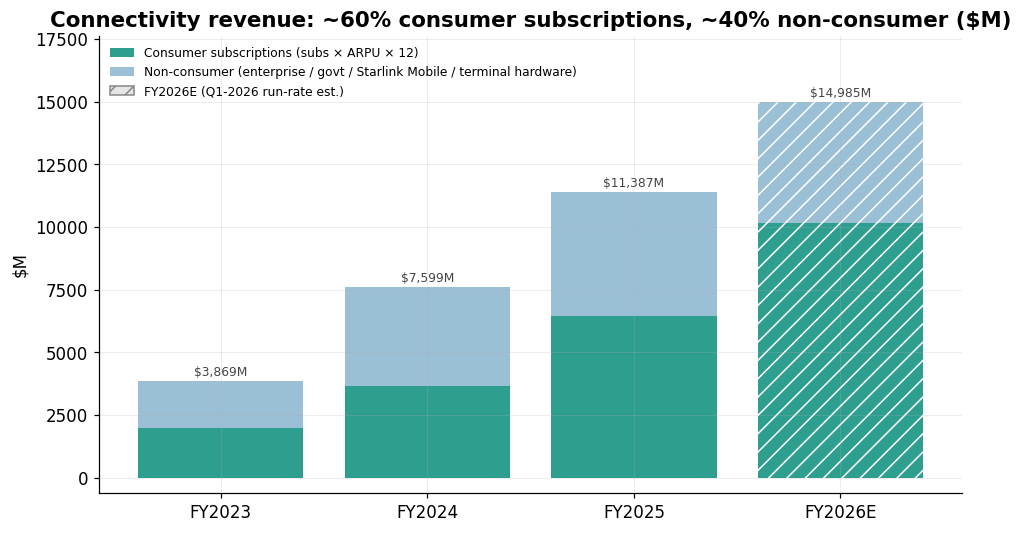

In [17]:
# Stacked Connectivity revenue: consumer (subs × ARPU × 12) vs non-consumer residual, with FY2026E.
# FY2026E uses the §3 convention (Q1-2026 / Q1-2025 YoY applied to FY2025 lines).
subs_yoy_q1  = sub["Q1-2026"]  / sub["Q1-2025"]                    # +105% YoY  (used here and in the next chart)
arpu_yoy_q1  = arpu["Q1-2026"] / arpu["Q1-2025"]                   # -23% YoY
subs_26e     = sub["FY2025"]   * subs_yoy_q1                       # 8.9 * 2.06 ≈ 18.3M
arpu_26e     = arpu["FY2025"]  * arpu_yoy_q1                       # 81  * 0.77 ≈ 62/mo
avg_subs_26e = (sub["FY2025"] + subs_26e) / 2
cons_26e     = avg_subs_26e * arpu_26e * 12
noncons_26e  = fy26e["revenue"] - cons_26e                          # fy26e from §3

cons    = list(mkt.loc[["FY2023","FY2024","FY2025"], "Consumer rev ($M)"])   + [cons_26e]
noncons = list(mkt.loc[["FY2023","FY2024","FY2025"], "Non-consumer ($M)"])   + [noncons_26e]
x       = np.arange(len(CHART_PERIODS))

fig, ax = plt.subplots()
b_c = ax.bar(x, cons,    color=TEAL,        label="Consumer subscriptions (subs × ARPU × 12)")
b_n = ax.bar(x, noncons, bottom=cons, color="#9bbfd4",
             label="Non-consumer (enterprise / govt / Starlink Mobile / terminal hardware)")
for bars in (b_c, b_n):
    bars[-1].set_hatch("//"); bars[-1].set_edgecolor("white"); bars[-1].set_linewidth(0)
for i in range(len(CHART_PERIODS)):
    total = cons[i] + noncons[i]
    ax.text(i, total + 200, f"${total:,.0f}M", ha="center", fontsize=8, color="#444")
ax.set_xticks(x); ax.set_xticklabels(CHART_PERIODS)
ax.set_title("Connectivity revenue: ~60% consumer subscriptions, ~40% non-consumer ($M)")
ax.set_ylabel("$M")
handles, _ = ax.get_legend_handles_labels()
handles.append(Patch(facecolor="0.9", edgecolor="#888", hatch="//", label="FY2026E (Q1-2026 run-rate est.)"))
ax.legend(handles=handles, fontsize=8)
charts.finish(fig); charts.pad_ylim(ax)
charts.save(fig, "connectivity_revenue_split", layout=False); plt.show()

### 7.2 ARPU is declining by design

The S-1 is explicit that ARPU falls on purpose, and says why (p. 88):
> *"We generally expect Starlink Subscriber ARPU to continue to decline over the next few years as the
> portion of our subscriber base outside North America continues to grow, as we add lower priced service
> plans, and as we adjust the monthly service plan fees we charge for broadband offerings. However, we
> expect these dynamics to be offset by increased scale and technological advancement in our launch,
> satellite, and user terminal operations, ultimately supporting overall revenue growth and cost reduction."*

> *"Our strategy is focused on driving sustainable revenue growth and expanding our margins through
> operational efficiencies and technological advancements, rather than prioritizing increases in ARPU."*

So ARPU decline has three drivers — **international mix shift, lower-priced plans, broadband price cuts** —
and one stated offset: **cost reduction in launch, satellites, and terminals**. We can't decompose the
three (no per-geography or per-plan ARPU is disclosed), so we measure the aggregate path and project a
floor. **Hold onto that offset — §7.6 tests whether it is large enough to keep the margin.**

Subscribers more than doubled in each of the last three years (+105% Q1-26 YoY). ARPU fell \$99 → \$81 over
FY23–25 (~-10%/yr), then stepped down to \$66 in Q1-26 (-23% YoY) as the international / low-priced mix
accelerated. FY2026E (hatched) applies the Q1 YoY rates to the full year.

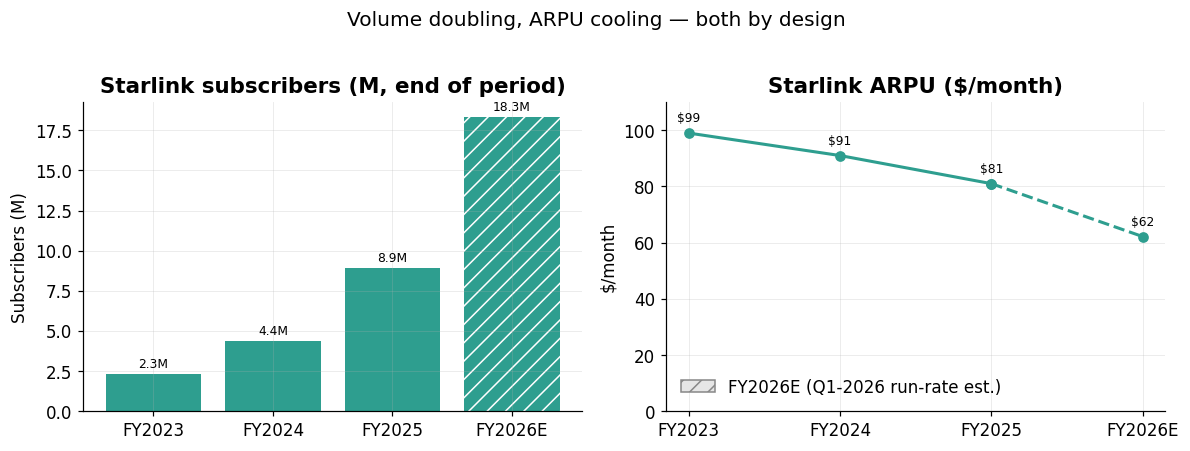

In [18]:
# Subscribers (bars) and ARPU (line) over time. FY2026E from §3 convention (defined in the chart above).
sub_series  = list(sub[["FY2023","FY2024","FY2025"]])  + [subs_26e]
arpu_series = list(arpu[["FY2023","FY2024","FY2025"]]) + [arpu_26e]
x = np.arange(len(CHART_PERIODS))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
b = ax1.bar(x, sub_series, color=TEAL)
b[-1].set_hatch("//"); b[-1].set_edgecolor("white"); b[-1].set_linewidth(0)
ax1.set_xticks(x); ax1.set_xticklabels(CHART_PERIODS)
ax1.set_title("Starlink subscribers (M, end of period)")
ax1.set_ylabel("Subscribers (M)")
for i, v in enumerate(sub_series):
    ax1.text(i, v + 0.4, f"{v:.1f}M", ha="center", fontsize=8)

ax2.plot(x[:3], arpu_series[:3], "o-",  color=TEAL, lw=2)
ax2.plot(x[2:], arpu_series[2:], "o--", color=TEAL, lw=2)
ax2.set_xticks(x); ax2.set_xticklabels(CHART_PERIODS)
ax2.set_title("Starlink ARPU ($/month)")
ax2.set_ylabel("$/month"); ax2.set_ylim(0, 110)
for i, v in enumerate(arpu_series):
    ax2.text(i, v + 4, f"${v:.0f}", ha="center", fontsize=8)
ax2.legend(handles=[Patch(facecolor="0.9", edgecolor="#888", hatch="//", label="FY2026E (Q1-2026 run-rate est.)")])
fig.suptitle("Volume doubling, ARPU cooling — both by design", y=1.02)
charts.finish(fig); charts.pad_ylim(ax)
charts.save(fig, "connectivity_subs_arpu", layout=False); plt.show()

### 7.3 Addressable market — \$1.6T headline, ~860M reachable households

The S-1's headline TAM is a *dollar* figure (p. 11): **\$1.6T** (\$870B Broadband + \$740B Mobile, plus
enterprise / government, ex-China/Russia). It bundles hardware and the whole downstream stack, so it is a
ceiling — not something to compare to subscription revenue.

The tighter bound is the **subscriber-side TAM**, built from one disclosed number (p. 4): Starlink aims to
connect **"over three billion unconnected people."** Convert people to households:

$$\text{unconnected households} = \frac{3.0\text{B people}}{3.5\text{ people/HH}} \approx 860\text{M HH}$$

3.5 people/HH is the global average (Euromonitor, cited S-1 p. 13). That ~860M is the **outer envelope** on
consumer subscribers. Enterprise / aviation / maritime / government pools are far smaller in unit count but
carry much higher ARPU, and feed the non-consumer stream.

In [19]:
# Subscriber-side TAM: count up the addressable pools and compare to current penetration.
PPL_PER_HH           = 3.5                       # global avg (UN/Euromonitor; S-1 cites Euromonitor p.13)
UNCONNECTED_PEOPLE_B = 3.0                       # S-1 p.4: "over three billion unconnected people"

unconnected_hh_M = UNCONNECTED_PEOPLE_B * 1000 / PPL_PER_HH    # ~857M households
current_subs_M   = sub["Q1-2026"]                              # 10.3M consumer subs

pools = pd.DataFrame([
    ["Unconnected households",     "S-1 p.4: ~3B people / 3.5 ppl-per-HH",        unconnected_hh_M],
    ["Commercial aircraft (global)","industry benchmark (Boeing/Airbus fleet)",    0.025],
    ["Commercial vessels >100GT",   "industry benchmark (UNCTAD/IMO merchant)",    0.080],
], columns=["Addressable pool","Source / derivation","Units (M)"])
display(fmt(pools.set_index("Addressable pool"), one=["Units (M)"]))

print(f"\nStarlink Subscribers Q1-2026: {current_subs_M:.1f}M consumer subs (Personal + Business plans)")
print(f"  -> {current_subs_M/unconnected_hh_M:.2%} of the ~{unconnected_hh_M:.0f}M unconnected-HH ceiling\n")

# What does each penetration step look like, in subs and revenue?
pen = pd.DataFrame({"Penetration of HH ceiling": [0.025, 0.05, 0.10, 0.15]})
pen["Implied subs (M)"]            = pen["Penetration of HH ceiling"] * unconnected_hh_M
pen["× current subs"]              = pen["Implied subs (M)"] / current_subs_M
pen["Annual rev @ $50/mo ($B)"]    = pen["Implied subs (M)"] * 50 * 12 / 1000
display(fmt(pen.set_index("Penetration of HH ceiling"),
            pct=["Penetration of HH ceiling"],
            one=["Implied subs (M)","× current subs","Annual rev @ $50/mo ($B)"]))

,Source / derivation,Units (M)
Addressable pool,,
Unconnected households,S-1 p.4: ~3B people / 3.5 ppl-per-HH,857.1
Commercial aircraft (global),industry benchmark (Boeing/Airbus fleet),0.0
Commercial vessels >100GT,industry benchmark (UNCTAD/IMO merchant),0.1



Starlink Subscribers Q1-2026: 10.3M consumer subs (Personal + Business plans)
  -> 1.20% of the ~857M unconnected-HH ceiling



,Implied subs (M),× current subs,Annual rev @ $50/mo ($B)
Penetration of HH ceiling,,,
0.025000,21.4,2.1,12.9
0.050000,42.9,4.2,25.7
0.100000,85.7,8.3,51.4
0.150000,128.6,12.5,77.1


### 7.4 Tightening the ceiling — substitution and affordability

860M is the envelope, not the reachable base. Two filters cut it down, and we apply both:

**Filter 1 — terrestrial substitution (adds a little back).** Where fiber / cable / DSL exists at adequate
quality it beats Starlink on cost-per-MB and latency (LEO ~25–50ms vs fiber ~5–10ms). The unconnected pool
is already net of this *by definition*; what this filter *adds back* is the slice of already-served
households where Starlink still wins (rural-within-served, business backup). We take **~5% of ~1B served HH
(ex-China/Russia) ≈ 50M HH.**

**Filter 2 — affordability (the binding constraint).** Starlink's cheapest international plans are ~\$30/mo
plus a \$199–\$499 terminal. Benchmarks: the ITU affordability line is ≤2% of GNI per capita → ~\$22/mo at
global per-capita GNI ≈ \$13K; the World Bank counts ~700M people under \$2.15/day and ~1.7B under
\$3.65/day. A large share of the 860M structurally cannot sustain Starlink's price floor regardless of
coverage. No subscriber income mix is disclosed, so we treat the income-capable share as a band:
**20–45% (central 30%).**

Cascading both filters gives the realistic ceiling:

$$\text{realistic ceiling} = \underbrace{(\text{income-capable \%} \times 860\text{M unconnected})}_{\text{Filter 2}} + \underbrace{(\text{win-share \%} \times 1{,}000\text{M served})}_{\text{Filter 1}}$$

The income-capable share and the Starlink-win share are sensitivity bands, not disclosures — neither SpaceX
nor the S-1 publishes them.

,Income-capable share of unconnected,Starlink-win share of served,Income-capable unconnected (M),Win-in-served (M),Realistic ceiling (M HH),Current penetration
Case,,,,,,
Tight,20.0%,3.0%,171.4,30.0,201.4,5.1%
Central,30.0%,5.0%,257.1,50.0,307.1,3.4%
Loose,45.0%,8.0%,385.7,80.0,465.7,2.2%



Raw envelope:                         857M HH  (1.20% current penetration)
Central realistic ceiling:            307M HH  (3.35% current penetration)


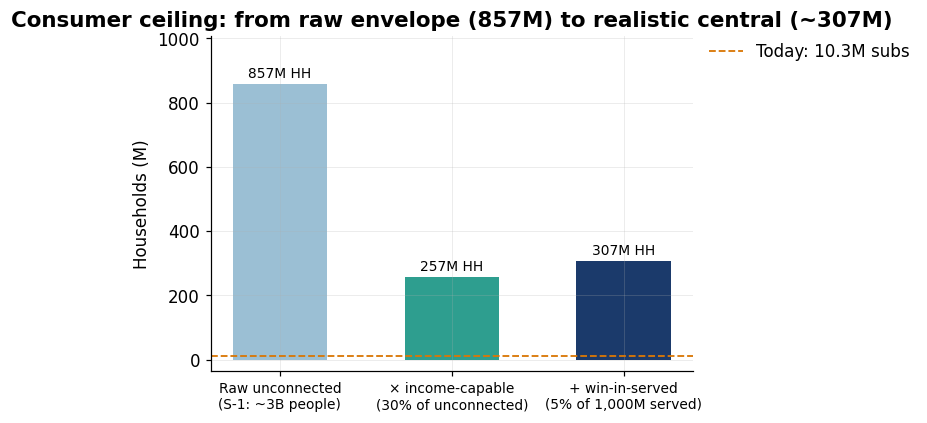

In [20]:
# Two filters on the raw 857M HH envelope to get a realistic consumer ceiling.
# Filter inputs are sensitivity bands — neither SpaceX nor the S-1 publishes a subscriber income split.
# External anchors:
#   - World Bank: ~700M people in extreme poverty (<$2.15/day); ~1.7B on <$3.65/day
#   - ITU: broadband affordability benchmark ≤2% of GNI per capita; global per-cap GNI ≈ $13K → ~$22/mo
#   - ITU: ~1.4B fixed-broadband HH globally; ~500M of those are in China → ~1.0B ex-China/Russia
SERVED_HH_M = 1000     # fixed-broadband HH globally ex-China/Russia (ITU; SpaceX excludes China/Russia from TAM)

ceiling = pd.DataFrame([
    ["Tight",   0.20, 0.03],
    ["Central", 0.30, 0.05],
    ["Loose",   0.45, 0.08],
], columns=["Case", "Income-capable share of unconnected", "Starlink-win share of served"])
ceiling["Income-capable unconnected (M)"] = ceiling["Income-capable share of unconnected"] * unconnected_hh_M
ceiling["Win-in-served (M)"]              = ceiling["Starlink-win share of served"]        * SERVED_HH_M
ceiling["Realistic ceiling (M HH)"]       = ceiling["Income-capable unconnected (M)"] + ceiling["Win-in-served (M)"]
ceiling["Current penetration"]            = current_subs_M / ceiling["Realistic ceiling (M HH)"]

display(fmt(ceiling.set_index("Case"),
            pct=["Income-capable share of unconnected","Starlink-win share of served","Current penetration"],
            one=["Income-capable unconnected (M)","Win-in-served (M)","Realistic ceiling (M HH)"]))

REALISTIC_CEILING_CENTRAL_M = ceiling.set_index("Case").loc["Central", "Realistic ceiling (M HH)"]
print(f"\nRaw envelope:                       {unconnected_hh_M:>5.0f}M HH  ({current_subs_M/unconnected_hh_M:>5.2%} current penetration)")
print(f"Central realistic ceiling:          {REALISTIC_CEILING_CENTRAL_M:>5.0f}M HH  ({current_subs_M/REALISTIC_CEILING_CENTRAL_M:>5.2%} current penetration)")

# Funnel chart: from raw envelope to realistic central ceiling
central = ceiling.set_index("Case").loc["Central"]
steps  = [unconnected_hh_M, central["Income-capable unconnected (M)"], central["Realistic ceiling (M HH)"]]
labels = ["Raw unconnected\n(S-1: ~3B people)",
          f"× income-capable\n({central['Income-capable share of unconnected']:.0%} of unconnected)",
          f"+ win-in-served\n({central['Starlink-win share of served']:.0%} of {SERVED_HH_M:,.0f}M served)"]
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(np.arange(3), steps, color=["#9bbfd4", TEAL, NAVY], width=0.55)
for i, v in enumerate(steps):
    ax.text(i, v + 20, f"{v:.0f}M HH", ha="center", fontsize=9)
ax.axhline(current_subs_M, color="#d97706", ls="--", lw=1.2, label=f"Today: {current_subs_M:.1f}M subs")
ax.set_xticks(np.arange(3)); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Households (M)")
ax.set_title("Consumer ceiling: from raw envelope (857M) to realistic central (~307M)")
charts.legend_outside(ax, loc="upper left")
charts.pad_ylim(ax); charts.finish(fig); charts.save(fig, "connectivity_realistic_ceiling", layout=False); plt.show()

The central case is a **~307M HH realistic ceiling** — about a third of the 860M envelope. Current subs are
~3.4% of it (vs the ~1.2% headline). Two consequences for the projection:

1. **The bull case starts to bind.** 97M subs by FY2030 is ~32% of the central ceiling (~48% of the tight
   case) — approaching saturation in a five-year window. Aggressive, not uncapped.
2. **ARPU and the ceiling are coupled.** Cutting ARPU toward \$35–45 internationally *raises* the
   income-capable share (more HH clear the affordability line), partly relaxing Filter 2. A deeper ARPU cut
   buys reachable households at the cost of revenue per sub — so the DCF should sensitize the two
   **jointly**, not as independent inputs.

The scenarios below report each case against **both** ceilings so the remaining headroom is visible.

### 7.5 Bear / base / bull through FY2030

Three decelerating subscriber paths (today's +105% can't last), three ARPU floors inside the S-1's
continued-decline guidance, a non-consumer growth band, and a held op-margin band. The op margin is an
*input* here — **§7.6 stress-tests whether the required satellite buildout actually supports it.**

| Lever | Bear | Base | Bull |
|---|---|---|---|
| Subscriber growth FY26→FY30 (% YoY) | 50/30/20/15/10 | 80/55/40/30/20 | 100/80/60/45/30 |
| ARPU floor by FY2030 (\$/mo) | \$35 | \$45 | \$55 |
| Non-consumer growth (% YoY, all years) | 15% | 25% | 40% |
| Operating margin held | 35% | 40% | 45% |

The mechanics, in two lines (ARPU glides linearly from \$81 to the floor over five years):

$$\text{consumer rev} = \text{avg subs} \times \text{ARPU} \times 12 \qquad
\text{op income} = (\text{consumer} + \text{non-consumer}) \times \text{op margin}$$

,Subs (M),ARPU ($/mo),Consumer rev ($M),Non-cons rev ($M),Total rev ($M),Op income ($M),× FY2025 rev,× FY2025 op,Raw HH pen.,Realistic pen.
Bear,26.3,35.0,"10,562","9,902","20,464","7,162",1.8,1.6,3.1%,8.6%
Base,54.2,45.0,"26,844","15,024","41,869","16,747",3.7,3.8,6.3%,17.7%
Bull,96.6,55.0,"56,419","26,478","82,897","37,304",7.3,8.4,11.3%,31.5%


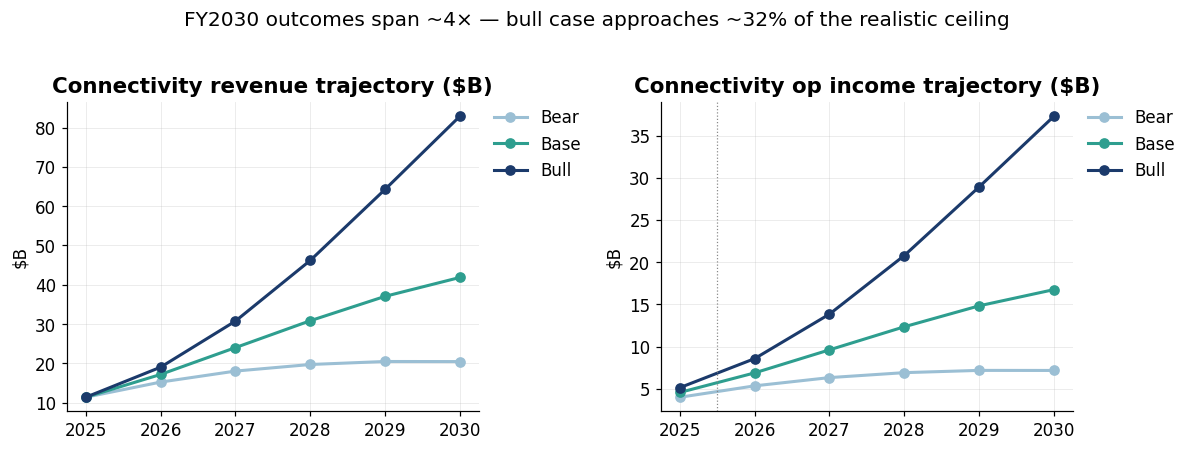

In [21]:
# Bear / base / bull projection through FY2030. Subscribers cross-checked against BOTH ceilings (§7.4).
YEARS = list(range(2025, 2031))                       # FY2025 anchor + FY2026–FY2030 forecast
scenarios = {
    "Bear": dict(sub_g=[0.50, 0.30, 0.20, 0.15, 0.10], arpu_floor=35, non_cons_g=0.15, op_margin=0.35),
    "Base": dict(sub_g=[0.80, 0.55, 0.40, 0.30, 0.20], arpu_floor=45, non_cons_g=0.25, op_margin=0.40),
    "Bull": dict(sub_g=[1.00, 0.80, 0.60, 0.45, 0.30], arpu_floor=55, non_cons_g=0.40, op_margin=0.45),
}
ANCHOR = dict(subs=sub["FY2025"], arpu=arpu["FY2025"],
              cons=mkt.loc["FY2025","Consumer rev ($M)"],
              noncons=mkt.loc["FY2025","Non-consumer ($M)"])

def project(case):
    s = scenarios[case]
    arpu_path = np.linspace(ANCHOR["arpu"], s["arpu_floor"], len(YEARS))   # straight glide to floor
    subs_prev, noncons_prev = ANCHOR["subs"], ANCHOR["noncons"]
    rows = []
    for i, yr in enumerate(YEARS):
        if i == 0:
            subs_eop, cons_rev, noncons = ANCHOR["subs"], ANCHOR["cons"], ANCHOR["noncons"]
        else:
            subs_eop = subs_prev * (1 + s["sub_g"][i-1])
            cons_rev = (subs_prev + subs_eop) / 2 * arpu_path[i] * 12      # avg subs * ARPU * months
            noncons  = noncons_prev * (1 + s["non_cons_g"])
        rev = cons_rev + noncons
        rows.append([yr, subs_eop, arpu_path[i], cons_rev, noncons, rev, rev * s["op_margin"]])
        subs_prev, noncons_prev = subs_eop, noncons
    return pd.DataFrame(rows, columns=["Year","Subs (M)","ARPU ($/mo)",
                                       "Consumer rev ($M)","Non-cons rev ($M)",
                                       "Total rev ($M)","Op income ($M)"]).set_index("Year")

proj = {c: project(c) for c in scenarios}

# FY2030 outcomes side by side, with BOTH ceiling penetrations (§7.4)
fy30 = pd.DataFrame({c: proj[c].loc[2030] for c in proj}).T
fy30["× FY2025 rev"]    = fy30["Total rev ($M)"] / R5["revenue"]["FY2025"]
fy30["× FY2025 op"]     = fy30["Op income ($M)"] / R5["op_income"]["FY2025"]
fy30["Raw HH pen."]     = fy30["Subs (M)"] / unconnected_hh_M
fy30["Realistic pen."]  = fy30["Subs (M)"] / REALISTIC_CEILING_CENTRAL_M
display(fmt(fy30, pct=["Raw HH pen.","Realistic pen."],
            one=["Subs (M)","ARPU ($/mo)","× FY2025 rev","× FY2025 op"]))

# Trajectory chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
COLORS = {"Bear":"#9bbfd4", "Base":TEAL, "Bull":NAVY}
for c in proj:
    ax1.plot(proj[c].index, proj[c]["Total rev ($M)"]/1000, "o-", color=COLORS[c], lw=2, label=c)
    ax2.plot(proj[c].index, proj[c]["Op income ($M)"]/1000, "o-", color=COLORS[c], lw=2, label=c)
for ax, title in [(ax1, "Connectivity revenue trajectory ($B)"),
                  (ax2, "Connectivity op income trajectory ($B)")]:
    ax.set_title(title); ax.set_ylabel("$B"); ax.set_xticks(YEARS); charts.legend_outside(ax)
ax.axvline(2025.5, color="#888", ls=":", lw=0.8)
fig.suptitle("FY2030 outcomes span ~4× — bull case approaches ~32% of the realistic ceiling", y=1.02)
charts.finish(fig); charts.save(fig, "connectivity_scenarios", layout=False); plt.show()

**What this gives the DCF.** A defensible **2030 revenue range of \$20–83B** (1.8–7.3× FY2025) and a segment
op-income range of **\$7–37B** (1.6–8.4× FY2025). Against the realistic central ceiling (~307M HH), the bull
case reaches ~32% penetration in five years — aggressive but not saturating; against the tight ceiling
(~200M) it is ~48%, the edge of credibility. The bear case sits at ~9% of central, leaving room for adverse
surprises.

Four knobs the DCF must sensitize:
- **ARPU floor** — a \$10/mo shift in the 2030 floor moves base-case consumer revenue by ~25%; the single
  most leveraged input.
- **Reachable ceiling** — tight (~200M) vs loose (~466M) more than doubles the bull case's headroom; coupled
  to the ARPU floor (§7.4), not independent.
- **Non-consumer growth** — no public sub count or ARPU; the 15–40% band brackets the stream's uncertainty.
- **Op margin** — held flat here, but it is not a free input: §7.6 shows the launch cadence and capex it
  quietly assumes.

### 7.6 Infrastructure: the launch cadence and capex behind the growth — and whether the margins survive it

The subscriber paths above assume an op margin. That margin is not free — it presupposes a satellite fleet
big enough to carry the traffic, refreshed as satellites deorbit, and built at a cost that does not outrun
revenue. Two equations govern it.

**1. How many launches the growth needs.** A satellite has a finite life, so each year's launches do two
jobs — replace the fleet that deorbits, and add capacity for new subscribers:

$$\text{launches}(t) = \frac{\overbrace{\text{fleet}/\text{life}}^{\text{replace}} + \overbrace{\Delta\text{fleet}}^{\text{grow}}}{\text{sats per launch}}
\qquad \text{fleet}(t) = \frac{\text{subscribers}(t)}{\text{capacity per satellite}(t)}$$

**2. Whether the margin holds.** Operating margin $= 1 - \tfrac{\text{cash opex}}{\text{rev}} - \tfrac{\text{D\&A}}{\text{rev}}$.
The fleet is depreciated, so the load-bearing term is depreciation ÷ revenue:

$$\frac{\text{depreciation}}{\text{revenue}} = \frac{\text{capex per sat}/\text{life}}{\text{revenue per sat}}
\qquad \text{revenue per sat} = \underbrace{\tfrac{\text{subs}}{\text{sat}}}_{\text{capacity}} \times \text{ARPU} \times 12$$

ARPU is falling **by design** (§7.2). So for depreciation/revenue to stay flat — and the assumed margin to
hold — **capacity per satellite must rise.** That is exactly the offset the S-1 names (§7.2: *"technological
advancement in our launch, satellite, and user terminal operations"*). Below we put numbers on it.

Anchors (only the **cost** is from the S-1; the satellite *count* is not disclosed, so it is an external
estimate, flagged like §6/§7.4):

| Input | Value | Source |
|---|---|---|
| Satellites per Falcon 9 launch | 23 | Starlink v2-mini (external; Starship raises this, so launch counts here are conservative) |
| Satellite useful life | 5 yr | deorbit / FCC license (≈ the ~4.5yr implied in §6) |
| Operational fleet, end-2025 | ~8,000 | external; ~7,500–8,000 per public trackers |
| All-in capex per launch | \$35.7M | FY2025 Satellites PP&E add ÷ launches (§6): sat hardware + launch cost |

FY2025 check: 122 launches = 70 replacement (fleet/life) + 52 growth  ->  net fleet 6,794 -> 8,000.
All-in capex $35.7M/launch (~$1.55M/sat); 1,112 subs/sat today.



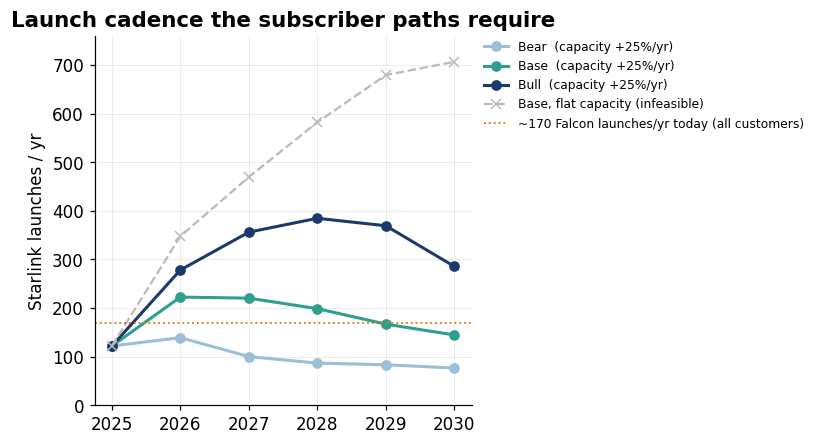

,Subs (M),Fleet (sats),Launches/yr,Sat capex ($M),Sat deprec. ($M)
2025,8.9,"8,000",122,"4,358","2,485"
2026,16.0,"11,520",223,"7,952","3,032"
2027,24.8,"14,285",220,"7,872","4,008"
2028,34.8,"15,999",199,"7,099","4,703"
2029,45.2,"16,639",167,"5,964","5,069"
2030,54.2,"15,973",145,"5,168","5,065"


In [22]:
# 7.6a Satellites -> launches each subscriber path requires.
SATS_PER_LAUNCH = 23                                   # Starlink v2-mini per Falcon 9 (external)
SAT_LIFE_YR     = 5.0                                  # deorbit/license life (≈ §6's ~4.5yr)
FLEET_2025      = 8000                                 # operational sats end-2025 (external)
CAPEX_PER_LAUNCH_M = sat_add25 / launches25            # $35.7M all-in (sat hardware + launch), from §6 PP&E add
CAPEX_PER_SAT_M    = CAPEX_PER_LAUNCH_M / SATS_PER_LAUNCH
subs_per_sat_2025  = sub["FY2025"] * 1e6 / FLEET_2025  # ~1,110 subscribers per operational satellite today

# FY2025 cross-check: the model should reproduce the 122 launches actually flown.
repl25   = FLEET_2025 / SAT_LIFE_YR
growth25 = launches25 * SATS_PER_LAUNCH - repl25
print(f"FY2025 check: {launches25:.0f} launches = {repl25/SATS_PER_LAUNCH:.0f} replacement (fleet/life) "
      f"+ {growth25/SATS_PER_LAUNCH:.0f} growth  ->  net fleet {FLEET_2025-growth25:,.0f} -> {FLEET_2025:,.0f}.")
print(f"All-in capex ${CAPEX_PER_LAUNCH_M:.1f}M/launch (~${CAPEX_PER_SAT_M:.2f}M/sat); {subs_per_sat_2025:,.0f} subs/sat today.\n")

CAP_G = 0.25     # central capacity-per-satellite gain /yr (v2-mini -> v3 + Starship). The key lever; flat case shown alongside.

def infra(case, cap_g):
    s = proj[case]["Subs (M)"]                                       # subscriber path from §7.5
    fleet, launches = [FLEET_2025], [float(launches25)]
    for i in range(1, len(YEARS)):
        sps  = subs_per_sat_2025 * (1 + cap_g) ** i                  # capacity per sat grows over time
        need = s.iloc[i] * 1e6 / sps                                 # fleet the subs require
        grow = max(0.0, need - fleet[-1]); repl = fleet[-1] / SAT_LIFE_YR
        launches.append((grow + repl) / SATS_PER_LAUNCH); fleet.append(need)
    fleet, launches = np.array(fleet), np.array(launches)
    avg_fleet = np.array([(fleet[max(0, i-1)] + fleet[i]) / 2 for i in range(len(fleet))])
    return pd.DataFrame({"Subs (M)": s.values, "Fleet (sats)": fleet, "Launches/yr": launches,
                         "Sat capex ($M)": launches * CAPEX_PER_LAUNCH_M,
                         "Sat deprec. ($M)": avg_fleet * CAPEX_PER_SAT_M / SAT_LIFE_YR,
                         "Total rev ($M)": proj[case]["Total rev ($M)"].values}, index=YEARS)

infra_c = {c: infra(c, CAP_G) for c in proj}      # central capacity gain
flat    = {c: infra(c, 0.0)   for c in proj}      # counterfactual: no capacity gain

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for c in proj:
    ax.plot(YEARS, infra_c[c]["Launches/yr"], "o-", color=COLORS[c], lw=2, label=f"{c}  (capacity +{CAP_G:.0%}/yr)")
ax.plot(YEARS, flat["Base"]["Launches/yr"], "x--", color="#bbb", lw=1.5, label="Base, flat capacity (infeasible)")
ax.axhline(170, color="#d97706", ls=":", lw=1.2, label="~170 Falcon launches/yr today (all customers)")
ax.set_xticks(YEARS); ax.set_ylabel("Starlink launches / yr"); ax.set_ylim(0, 760)
ax.set_title("Launch cadence the subscriber paths require")
charts.legend_outside(ax, fontsize=8, loc="upper left")
charts.finish(fig); charts.save(fig, "connectivity_launch_cadence", layout=False); plt.show()

display(fmt(infra_c["Base"][["Subs (M)", "Fleet (sats)", "Launches/yr", "Sat capex ($M)", "Sat deprec. ($M)"]],
            one=["Subs (M)"]))

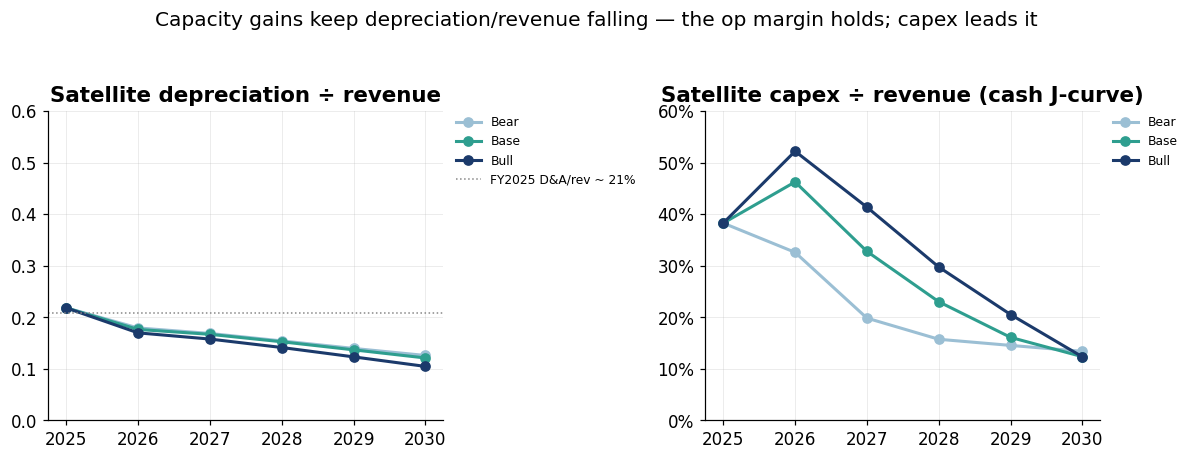

,Cum. launches 26–30,Cum. sat capex 26–30 ($B),Deprec./rev FY2030,Op margin assumed
Bear,486.1,17.4,12.6%,35.0%
Base,953.4,34.1,12.1%,40.0%
Bull,"1,674.0",59.8,10.5%,45.0%


In [23]:
# 7.6b Does the buildout break the assumed op margin? Track depreciation and capex against revenue.
fy25_da_rev = R.da["FY2025"] / R.revenue["FY2025"]      # ~21% reported D&A/revenue, the benchmark to beat

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for c in proj:
    d = infra_c[c]
    ax1.plot(YEARS, d["Sat deprec. ($M)"] / d["Total rev ($M)"], "o-", color=COLORS[c], lw=2, label=c)
    ax2.plot(YEARS, d["Sat capex ($M)"]   / d["Total rev ($M)"], "o-", color=COLORS[c], lw=2, label=c)
ax1.axhline(fy25_da_rev, color="#888", ls=":", lw=1, label=f"FY2025 D&A/rev ~ {fy25_da_rev:.0%}")
ax1.set_title("Satellite depreciation ÷ revenue")
ax2.set_title("Satellite capex ÷ revenue (cash J-curve)")
for ax in (ax1, ax2):
    ax.set_xticks(YEARS); ax.set_ylim(0, 0.6); charts.legend_outside(ax, fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
fig.suptitle("Capacity gains keep depreciation/revenue falling — the op margin holds; capex leads it", y=1.04)
fig.tight_layout(rect=[0, 0, 1, 0.93])
charts.save(fig, "connectivity_margin_check"); plt.show()

chk = pd.DataFrame({
    "Cum. launches 26–30":        {c: infra_c[c]["Launches/yr"].iloc[1:].sum()         for c in proj},
    "Cum. sat capex 26–30 ($B)":  {c: infra_c[c]["Sat capex ($M)"].iloc[1:].sum()/1000 for c in proj},
    "Deprec./rev FY2030":              {c: infra_c[c]["Sat deprec. ($M)"].iloc[-1] / infra_c[c]["Total rev ($M)"].iloc[-1] for c in proj},
    "Op margin assumed":               {c: scenarios[c]["op_margin"] for c in proj},
})
display(fmt(chk, pct=["Deprec./rev FY2030", "Op margin assumed"],
           one=["Cum. launches 26–30", "Cum. sat capex 26–30 ($B)"]))

**The margins hold — but only because capacity per satellite rises.** Two findings:

- **Feasibility is a capacity bet.** At today's ~23 sats/launch with *flat* capacity per satellite, the base
  case needs ~350 → 700 launches/yr and the bull case ~400 → 1,450 — multiples of the ~170 Falcon launches
  SpaceX flies for *all* customers today. Impossible on Falcon. The growth only closes if each launch carries
  far more usable capacity (v3 satellites + Starship). At ~+25%/yr capacity per satellite the cadence falls to
  ~150–220/yr (base) and ~280–385/yr (bull) — demanding, and squarely the ~200+ Starlink launches/yr that
  follows.
- **The margin is the same bet.** Satellite depreciation/revenue *falls* from ~20% (FY2025) toward ~10–13% by
  FY2030 in every scenario, because revenue per satellite (capacity × ARPU) rises even as ARPU declines. So the
  held op margins of **35 / 40 / 45% are consistent — even slightly conservative on the depreciation line —
  *given* the capacity gains.** This quantifies the S-1's stated ARPU-decline offset (§7.2): **the very capacity
  improvement that makes the launch cadence feasible is what holds the margin.** If it stalls, both break
  together — the cadence becomes impossible *and* depreciation/revenue climbs.

**Two cautions for the DCF, both on cash, not margin.** (1) Capex *leads* revenue — satellite capex runs
~40–50% of revenue in the early build years before falling, so FCF margin sits well below op margin during the
ramp (the §3 J-curve). Cumulative 2026–30 satellite capex is ~\$17B (bear) / \$34B (base) / \$60B (bull).
(2) Capacity-per-satellite growth deserves to be its own DCF lever: it sets both the capex line and the feasible
launch cadence, and it is coupled to the ARPU floor (lower ARPU is only survivable if capacity climbs).

**Carried forward to the Space-segment section:** the **~150–385 Starlink launches/yr** these paths imply, at
the ~\$17.5M internal launch cost from §6, set the intercompany launch volume we strip out of Space to recover
its third-party profitability.

### 7.7 The affordability–cost flywheel — one deterministic forward path

§7.5 held **op margin flat** and swept subscriber growth and ARPU floors as independent knobs. That is the
right shape for a DCF sensitivity grid, but it hides a **coupled story** the S-1 itself describes: ARPU falls
*on purpose* to reach more households (§7.2), and **technological cost decline** — cheaper launches, more
bandwidth per satellite — is the stated offset (§7.2, §7.6).

This section builds **one internally consistent path** through FY2030, not bear/base/bull:

| Lever | Direction | Justification |
|---|---|---|
| **ARPU** | Falls faster, to **\$38/mo** by FY2030 | Q1-26 ARPU already **\$66/mo** (−23% YoY); S-1 cites international mix + lower-priced plans (§7.2) |
| **Reachable ceiling** | **Expands** as ARPU falls | §7.4 coupling: lower price clears the ITU ~2%-of-GNI affordability line for more unconnected HH |
| **Subscribers** | Faster ramp toward the **expanded** ceiling | More HH reachable at \$38 than at \$81, even though revenue *per* sub is lower |
| **Launch cost** | **\$17.5M → \$8M**/launch | Starship internal cost target (§6 anchor → Starship commercial cadence) |
| **Sats / launch** | **23 → 60** | v2-mini on Falcon today → v3 batches on Starship (external; §7.6 uses 23 conservatively) |
| **Capacity / satellite** | **+30%/yr** | v3 + beamforming; slightly above §7.6's +25% central because Starship enables heavier payloads |
| **Op margin** | **Computed**, not assumed | FY2025 cash opex/rev held (modest scale benefit); D&A/rev falls as cost-per-delivered-bit drops |

The result is a single headline P&L the DCF can cite as the *"ARPU down, margin up, subs faster"* scenario —
the flywheel SpaceX describes, quantified with our existing inputs.


In [24]:
# 7.7a — Parameters and the ARPU ↔ ceiling coupling from §7.4.
# Every input below is either an S-1 anchor, a prior section's number, or a single external estimate (flagged).

# --- ARPU path (propensity-to-pay decelerates) ---
ARPU_26E  = arpu_26e                                    # $62/mo — §3 FY2026E run-rate (Q1 YoY applied)
ARPU_2030 = 38.0                                        # faster glide than base ($45); ITU-affordable band

# --- Dynamic consumer ceiling (§7.4 coupling) ---
REF_ARPU         = 65.0                                 # ARPU the central 307M ceiling was calibrated near
REF_INCOME_SHARE = 0.30                                 # §7.4 central "income-capable" share of unconnected
CEILING_ELASTIC  = 0.40                                 # sublinear: lower ARPU expands reach, not 1:1
WIN_SHARE        = 0.05                                 # §7.4 central Starlink-win share of served HH

def dynamic_ceiling(arpu_mo):
    """Reachable HH ceiling rises as ARPU falls below the §7.4 reference."""
    income_share = min(0.52, REF_INCOME_SHARE * (REF_ARPU / arpu_mo) ** CEILING_ELASTIC)
    return income_share * unconnected_hh_M + WIN_SHARE * SERVED_HH_M

# --- Subscriber ramp (deterministic, ceiling-constrained) ---
SUB_G_YOY       = [0.85, 0.65, 0.48, 0.32, 0.20]        # FY26–30 YoY; faster early ramp than base (0.80…0.20)
PEN_OF_CEILING  = 0.58                                  # approach 58% of the *dynamic* ceiling by FY2030
NONC_G          = 0.22                                  # non-consumer (aviation, maritime, MNO) — mid-band

# --- Infrastructure cost decline (Starship + v3) ---
LAUNCH_COST_30  = 8.0                                    # $M internal/launch by FY2030 (Starship target)
SATS_LAUNCH_30  = 60                                     # v3 batch on Starship (external; §7.6 uses 23 on Falcon)
CAP_G_FLY       = 0.30                                   # capacity per satellite / yr (+30%; §7.6 central = +25%)
SAT_MFG_LEARN   = 0.03                                   # 3%/yr satellite-manufacturing efficiency
SAT_MFG_SHARE_25 = 1 - (INTERNAL_LAUNCH_COST_M * launches25 / sat_add25)  # §6 implied ~45% mfg share

# FY2025 margin decomposition — cash opex held, D&A computed from fleet (not flat margin assumption)
CASH_OPEX_REV_25 = ((R.cogs["FY2025"] - R.da["FY2025"]) + R.rnd["FY2025"] + R.sga["FY2025"]) / R.revenue["FY2025"]
CASH_OPEX_SCALE  = 0.995                                 # −0.5%/yr scale benefit on kit + network ops

# ARPU glide: FY2025 anchor → FY2026E run-rate → accelerated decline to $38
arpu_fly = np.zeros(len(YEARS))
arpu_fly[0] = ANCHOR["arpu"]
arpu_fly[1] = ARPU_26E
for i in range(2, len(YEARS)):
    t = (i - 1) / (len(YEARS) - 2)
    arpu_fly[i] = ARPU_26E + (ARPU_2030 - ARPU_26E) * t ** 1.2   # front-loaded post-2026 decline

ceil_fly = np.array([dynamic_ceiling(a) for a in arpu_fly])

param_tbl = pd.DataFrame([
    ["ARPU FY2030",              f"${ARPU_2030:.0f}/mo",       "Q1-26 −23% YoY trajectory; faster than base $45"],
    ["Ceiling FY2030",           f"{ceil_fly[-1]:.0f}M HH",     "§7.4 income filter × affordability expansion"],
    ["vs central 307M",          f"+{(ceil_fly[-1]/REALISTIC_CEILING_CENTRAL_M - 1):.0%}", "Buys subs; costs revenue/sub"],
    ["Launch cost FY2030",       f"${LAUNCH_COST_30:.0f}M",    "Starship internal (§6 $17.5M → Starship)"],
    ["Sats / launch FY2030",     f"{SATS_LAUNCH_30}",          "v3 on Starship (§7.6 today: 23 on Falcon)"],
    ["Capacity / sat growth",    f"+{CAP_G_FLY:.0%}/yr",       "v3 + Starship payloads (§7.6: +25%)"],
    ["Op margin FY2030",         "computed",                   "1 − cash opex/rev − satellite D&A/rev"],
], columns=["Input", "Value", "Source / note"])
display(param_tbl.set_index("Input"))


,Value,Source / note
Input,,
ARPU FY2030,$38/mo,Q1-26 −23% YoY trajectory; faster than base $45
Ceiling FY2030,369M HH,§7.4 income filter × affordability expansion
vs central 307M,+20%,Buys subs; costs revenue/sub
Launch cost FY2030,$8M,Starship internal (§6 $17.5M → Starship)
Sats / launch FY2030,60,v3 on Starship (§7.6 today: 23 on Falcon)
Capacity / sat growth,+30%/yr,v3 + Starship payloads (§7.6: +25%)
Op margin FY2030,computed,1 − cash opex/rev − satellite D&A/rev


In [25]:
# 7.7b — Build the coupled subscriber × ARPU × revenue path; margin from infrastructure (next cell).

def launch_economics(i):
    """All-in capex per launch and sats/launch glide from Falcon FY2025 → Starship FY2030."""
    t = i / (len(YEARS) - 1)
    lc  = INTERNAL_LAUNCH_COST_M + (LAUNCH_COST_30 - INTERNAL_LAUNCH_COST_M) * t
    spl = SATS_PER_LAUNCH + (SATS_LAUNCH_30 - SATS_PER_LAUNCH) * t
    mfg = CAPEX_PER_LAUNCH_M * SAT_MFG_SHARE_25 * (1 - SAT_MFG_LEARN) ** i
    return lc + mfg, spl

def flywheel_path():
    subs_prev, nc_prev = ANCHOR["subs"], ANCHOR["noncons"]
    fleet = [FLEET_2025]
    launches = [float(launches25)]
    rows = []
    for i, yr in enumerate(YEARS):
        ceil = dynamic_ceiling(arpu_fly[i])
        if i == 0:
            subs_eop, cons, nc = subs_prev, ANCHOR["cons"], nc_prev
            sat_dep, sat_capex = R.da["FY2025"], R.capex["FY2025"]
        else:
            target = ceil * PEN_OF_CEILING
            subs_eop = min(subs_prev * (1 + SUB_G_YOY[i - 1]), target)
            cons = (subs_prev + subs_eop) / 2 * arpu_fly[i] * 12
            nc = nc_prev * (1 + NONC_G)
            sps = subs_per_sat_2025 * (1 + CAP_G_FLY) ** i
            need = subs_eop * 1e6 / sps
            grow = max(0.0, need - fleet[-1])
            repl = fleet[-1] / SAT_LIFE_YR
            cpl, spl = launch_economics(i)
            launches.append((grow + repl) / spl)
            fleet.append(need)
            avg_fleet = (fleet[-2] + fleet[-1]) / 2
            cps = cpl / spl
            sat_dep = avg_fleet * cps / SAT_LIFE_YR
            sat_capex = launches[-1] * cpl
        rev = cons + nc
        cash_ox = CASH_OPEX_REV_25 * (CASH_OPEX_SCALE ** i)
        da_rev = sat_dep / rev
        op_m = 1 - cash_ox - da_rev
        rows.append({
            "Year": yr, "Subs (M)": subs_eop, "ARPU ($/mo)": arpu_fly[i],
            "Ceiling (M HH)": ceil, "Penetration": subs_eop / ceil,
            "Consumer rev ($M)": cons, "Non-cons rev ($M)": nc, "Total rev ($M)": rev,
            "Cash opex/rev": cash_ox, "Sat D&A/rev": da_rev, "Op margin": op_m,
            "Op income ($M)": rev * op_m,
            "Launches/yr": launches[i], "Sat capex ($M)": sat_capex, "Sat deprec. ($M)": sat_dep,
        })
        subs_prev, nc_prev = subs_eop, nc
    return pd.DataFrame(rows).set_index("Year")

fly = flywheel_path()

# Headline table — FY2026 onward is the forward estimate
headline = fly[["Subs (M)", "ARPU ($/mo)", "Ceiling (M HH)", "Penetration",
                "Total rev ($M)", "Op income ($M)", "Op margin", "Sat D&A/rev", "Launches/yr"]].copy()
headline["× FY2025 rev"] = headline["Total rev ($M)"] / R.revenue["FY2025"]
headline["× FY2025 op"]  = headline["Op income ($M)"] / R.op_income["FY2025"]
display(fmt(headline.loc[2026:],
            pct=["Penetration", "Op margin", "Sat D&A/rev", "× FY2025 rev", "× FY2025 op"],
            one=["Subs (M)", "ARPU ($/mo)", "Ceiling (M HH)", "Launches/yr", "× FY2025 rev", "× FY2025 op"]))


,Subs (M),ARPU ($/mo),Ceiling (M HH),Penetration,Total rev ($M),Op income ($M),Op margin,Sat D&A/rev,Launches/yr,× FY2025 rev,× FY2025 op
Year,,,,,,,,,,,
2026,16.5,62.2,311.8,5.3%,"15,467","7,144",46.2%,13.7%,164.0,135.8%,161.5%
2027,27.2,57.6,319.9,8.5%,"22,403","11,358",50.7%,9.4%,141.3,196.7%,256.8%
2028,40.2,51.6,331.9,12.1%,"29,817","16,039",53.8%,6.5%,108.2,261.9%,362.6%
2029,53.1,45.1,347.7,15.3%,"36,123","20,216",56.0%,4.5%,67.4,317.2%,457.1%
2030,63.7,38.0,368.7,17.3%,"39,928","22,972",57.5%,3.2%,55.7,350.6%,519.4%


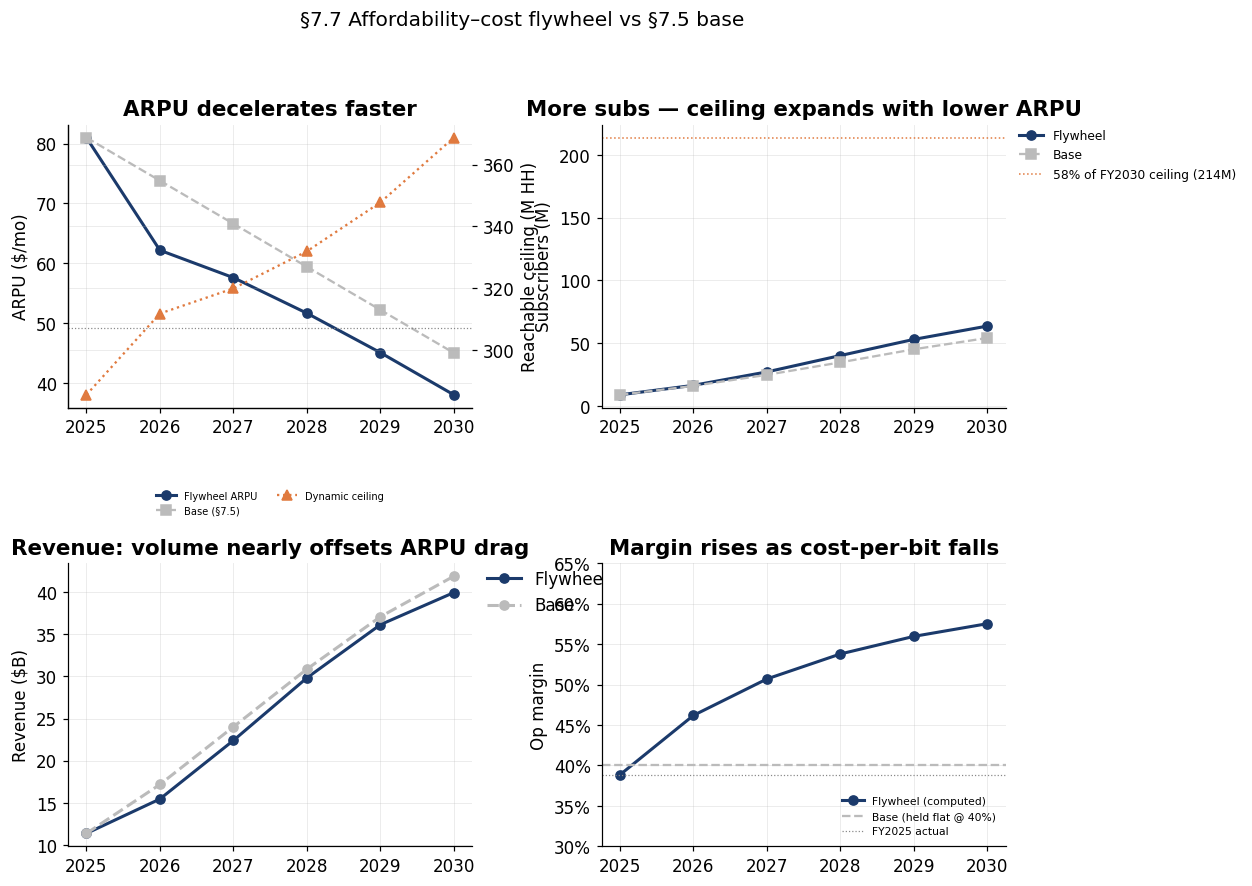

FY2030: 56 launches/yr  |  D&A/rev 3% (FY2025: 21%)  |  Cum sat capex FY26–30: $16.0B


,Launches/yr,Sat deprec./rev,Sat capex/rev
Year,,,
2026,164.0,13.7%,35.3%
2027,141.3,9.4%,19.5%
2028,108.2,6.5%,10.3%
2029,67.4,4.5%,4.9%
2030,55.7,3.2%,3.3%


In [26]:
# 7.7c — Visual: the flywheel vs the §7.5 base case (flat margin, no ceiling coupling).
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Panel 1: ARPU — faster decline, expanded ceiling on twin axis
ax = axes[0, 0]
ax.plot(YEARS, fly["ARPU ($/mo)"], "o-", color=NAVY, lw=2, label="Flywheel ARPU")
ax.plot(YEARS, proj["Base"]["ARPU ($/mo)"], "s--", color="#bbb", lw=1.5, label="Base (§7.5)")
ax.set_ylabel("ARPU ($/mo)"); ax.set_title("ARPU decelerates faster")
ax2 = ax.twinx()
ax2.plot(YEARS, fly["Ceiling (M HH)"], "^:", color=ORANGE, lw=1.5, label="Dynamic ceiling")
ax2.axhline(REALISTIC_CEILING_CENTRAL_M, color="#888", ls=":", lw=0.8)
ax2.set_ylabel("Reachable ceiling (M HH)")
charts.legend_merged(ax, ax2, fontsize=6.5, loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2)

# Panel 2: subscribers
ax = axes[0, 1]
ax.plot(YEARS, fly["Subs (M)"], "o-", color=NAVY, lw=2, label="Flywheel")
ax.plot(YEARS, proj["Base"]["Subs (M)"], "s--", color="#bbb", lw=1.5, label="Base")
ax.axhline(fly.loc[2030, "Ceiling (M HH)"] * PEN_OF_CEILING, color=ORANGE, ls=":", lw=1,
           label=f"58% of FY2030 ceiling ({fly.loc[2030,'Ceiling (M HH)']*PEN_OF_CEILING:.0f}M)")
ax.set_ylabel("Subscribers (M)"); ax.set_title("More subs — ceiling expands with lower ARPU")
charts.legend_outside(ax, fontsize=8, loc="upper left")

# Panel 3: revenue (lower ARPU, more subs → net effect)
ax = axes[1, 0]
for label, df, c, ls in [("Flywheel", fly, NAVY, "-"), ("Base", proj["Base"], "#bbb", "--")]:
    ax.plot(YEARS, df["Total rev ($M)"] / 1000, f"o{ls}", color=c, lw=2, label=label)
ax.set_ylabel("Revenue ($B)"); ax.set_title("Revenue: volume nearly offsets ARPU drag")
charts.legend_outside(ax, loc="upper left")

# Panel 4: op margin — computed vs flat assumption
ax = axes[1, 1]
ax.plot(YEARS, fly["Op margin"], "o-", color=NAVY, lw=2, label="Flywheel (computed)")
ax.axhline(scenarios["Base"]["op_margin"], color="#bbb", ls="--", lw=1.5, label="Base (held flat @ 40%)")
ax.axhline(R.op_income["FY2025"] / R.revenue["FY2025"], color="#888", ls=":", lw=0.8, label="FY2025 actual")
ax.set_ylabel("Op margin"); ax.set_ylim(0.30, 0.65)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Margin rises as cost-per-bit falls")
ax.legend(fontsize=7, loc="lower right")

for ax in axes.flat:
    ax.set_xticks(YEARS)
fig.suptitle("§7.7 Affordability–cost flywheel vs §7.5 base", y=1.03)
fig.subplots_adjust(hspace=0.55, wspace=0.32, top=0.90, bottom=0.08)
charts.save(fig, "connectivity_flywheel", layout=False); plt.show()

# Infrastructure sanity check
infra_fly = fly[["Subs (M)", "Launches/yr", "Sat capex ($M)", "Sat deprec. ($M)", "Total rev ($M)"]].copy()
infra_fly["Sat deprec./rev"] = infra_fly["Sat deprec. ($M)"] / infra_fly["Total rev ($M)"]
infra_fly["Sat capex/rev"]   = infra_fly["Sat capex ($M)"]   / infra_fly["Total rev ($M)"]
print(f"FY2030: {fly.loc[2030,'Launches/yr']:.0f} launches/yr  |  "
      f"D&A/rev {fly.loc[2030,'Sat D&A/rev']:.0%} (FY2025: {R.da['FY2025']/R.revenue['FY2025']:.0%})  |  "
      f"Cum sat capex FY26–30: ${fly.loc[2026:2030,'Sat capex ($M)'].sum()/1000:.1f}B")
display(fmt(infra_fly.loc[2026:, ["Launches/yr", "Sat deprec./rev", "Sat capex/rev"]],
            pct=["Sat deprec./rev", "Sat capex/rev"], one=["Launches/yr"]))


**FY2030 headline numbers (deterministic flywheel path):**

| | FY2025 (actual) | FY2030 (flywheel) | × FY2025 |
|---|---:|---:|---:|
| Subscribers | 8.9M | **~64M** | 7.2× |
| ARPU | \$81/mo | **\$38/mo** | −53% |
| Reachable ceiling | 307M HH (static central) | **~369M HH** (dynamic) | +20% |
| Revenue | \$11.4B | **~\$40B** | 3.5× |
| Op income | \$4.4B | **~\$23B** | 5.2× |
| Op margin | 39% | **~57%** | +18 pp |
| Satellite D&A / rev | 21% | **~3%** | cost-per-bit wins |

**How to read this vs §7.5.** The base case ends FY2030 at ~54M subs and \$45 ARPU with margin *assumed*
flat at 40% (~\$42B revenue, ~\$17B op income). The flywheel path trades **\$7/mo of ARPU** for
**~10M more subscribers** and a **computed** margin ~17 pp higher — because Starship launch economics and
v3 capacity gains drop depreciation per delivered gigabit faster than ARPU falls. Revenue lands *modestly
below* base (~\$40B vs ~\$42B) but **operating income is ~\$6B higher** (~\$23B vs ~\$17B): this is the
S-1's stated strategy rendered as a P&L.

**What the DCF should take from this.** Not a fourth scenario alongside bear/base/bull — a **single coherent
alternative** where the §7.4 ceiling coupling and §7.6 infrastructure bet are switched on together. The
binding constraint is still the capacity curve (+30%/yr); if that stalls, ARPU cannot fall this far *and*
keep the margin. The flywheel only closes if the cost side is real.


## 8. Forward free cash flow — how much cash the growth actually returns (FY2026–FY2030)

§3 measured the cash Starlink threw off *historically*; §7 projected the revenue, operating income, and the
satellite buildout the growth requires. **§7.7 adds one deterministic "flywheel" path** — ARPU
falls faster, the ceiling expands, and margin is *computed* from Starship economics rather than held
flat — which §8a also closes to cash below. This section closes the loop with the only forward number that matters
for valuation: **free cash flow, per scenario, through FY2030.**

**Method — the §3 FCF definition, projected forward.** For each scenario:

$$\text{FCF} = \underbrace{\text{operating income}}_{\S7.5} + \underbrace{\text{D\&A} + \text{SBC}}_{\text{non-cash add-backs}} - \underbrace{\text{capex}}_{\S7.6}$$

Operating income comes from the subscriber/ARPU paths (§7.5); **D&A and capex are the satellite-fleet figures
those paths physically require** (§7.6), so the cash cost of building *and* replacing the constellation is
carried straight through. SBC is held at its FY2025 share of revenue (~3%). FY2025 is anchored to the reported
\$3.0B actual; FY2026–FY2030 are the forecast.

**Three honest flags the DCF must carry:**
- **Pre-tax.** SpaceX is consolidated loss-making with large NOLs, so near-term cash taxes ≈ 0 and we keep
  operating income pre-tax. A mature standalone Starlink would eventually pay tax; the summary shows a *what-if*
  21% line for scale. The DCF layers in cash tax once NOLs exhaust.
- **SBC is added back as non-cash but is real dilution** (~\$0.5–2.7B/yr). Cash an owner can actually keep is
  closer to **FCF − SBC**, also shown.
- **Working capital excluded → conservative.** Prepaid subscriptions are a cash *source*, so true CFO (and FCF)
  runs a little higher than this.

This is **unlevered** FCF (no segment debt) — exactly the cash a DCF discounts.

In [27]:
# 8a. Forward FCF per scenario = op income (§7.5) + D&A + SBC - capex (§7.6).  Same definition as §3.
SBC_PCT = R.sbc["FY2025"] / R.revenue["FY2025"]                            # ~3.2% of revenue, held flat
FCF25   = (R.op_income + R.da + R.sbc + R.impairment - R.capex)["FY2025"]  # $2,990M reported actual (anchor)

def fcf_path(case):
    p, d = proj[case], infra_c[case]                       # §7.5 P&L path, §7.6 satellite capex/deprec
    t = pd.DataFrame(index=YEARS)
    t["Revenue"]    = p["Total rev ($M)"]
    t["Op income"]  = p["Op income ($M)"]
    t["+ D&A"]      = d["Sat deprec. ($M)"]
    t["+ SBC"]      = p["Total rev ($M)"] * SBC_PCT
    t["- Capex"]    = -d["Sat capex ($M)"]
    t["= FCF"]      = t["Op income"] + t["+ D&A"] + t["+ SBC"] + t["- Capex"]
    t["FCF margin"] = t["= FCF"] / t["Revenue"]
    t["FCF - SBC (distributable)"] = t["= FCF"] - t["+ SBC"]
    return t

fcf = {c: fcf_path(c) for c in scenarios}
display(fmt(fcf["Base"].loc[2026:], pct=["FCF margin"]))   # base case shown; all three in the summary (8c)
# §7.7 flywheel — same FCF bridge, but op income + capex/D&A come from the coupled path (not §7.5/§7.6).
def fcf_flywheel():
    t = pd.DataFrame(index=YEARS)
    t["Revenue"]    = fly["Total rev ($M)"]
    t["Op income"]  = fly["Op income ($M)"]
    t["+ D&A"]      = fly["Sat deprec. ($M)"]
    t["+ SBC"]      = fly["Total rev ($M)"] * SBC_PCT
    t["- Capex"]    = -fly["Sat capex ($M)"]
    t["= FCF"]      = t["Op income"] + t["+ D&A"] + t["+ SBC"] + t["- Capex"]
    t["FCF margin"] = t["= FCF"] / t["Revenue"]
    t["FCF - SBC (distributable)"] = t["= FCF"] - t["+ SBC"]
    return t

fcf_fly = fcf_flywheel()


,Revenue,Op income,+ D&A,+ SBC,- Capex,= FCF,FCF margin,FCF - SBC (distributable)
2026,"17,189","6,875","3,032",557,"-7,952","2,512",14.6%,"1,955"
2027,"24,017","9,607","4,008",778,"-7,872","6,520",27.1%,"5,742"
2028,"30,855","12,342","4,703","1,000","-7,099","10,946",35.5%,"9,946"
2029,"37,062","14,825","5,069","1,201","-5,964","15,131",40.8%,"13,930"
2030,"41,869","16,747","5,065","1,357","-5,168","18,001",43.0%,"16,644"


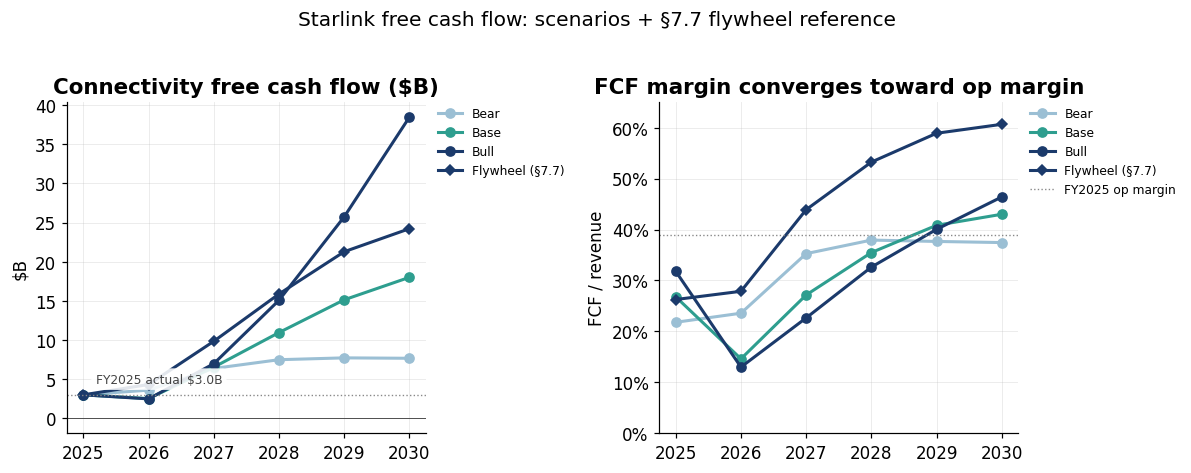

In [28]:
# 8b. The J-curve doesn't end - it pauses: FCF dips in 2026 as capex front-runs the ramp, then climbs.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
yrs = [2025] + list(range(2026, 2031))
for c in scenarios:
    series = [FCF25 / 1000] + list(fcf[c]["= FCF"].loc[2026:].values / 1000)   # FY2025 actual + forecast
    ax1.plot(yrs, series, "o-", color=COLORS[c], lw=2, label=c)
    ax2.plot(YEARS, fcf[c]["FCF margin"], "o-", color=COLORS[c], lw=2, label=c)
# §7.7 flywheel — deterministic reference, not a fourth sensitivity case
fly_series = [FCF25 / 1000] + list(fcf_fly["= FCF"].loc[2026:].values / 1000)
ax1.plot(yrs, fly_series, "D-", color=NAVY, lw=2, ms=5, label="Flywheel (§7.7)")
ax2.plot(YEARS, fcf_fly["FCF margin"], "D-", color=NAVY, lw=2, ms=5, label="Flywheel (§7.7)")
ax1.axhline(FCF25 / 1000, color="#888", ls=":", lw=0.9)
charts.annotate_clear(ax1, f"FY2025 actual ${FCF25/1000:.1f}B", (2025, FCF25/1000),
             textcoords="offset points", xytext=(8, 8), fontsize=8, color="#444")
ax1.axhline(0, color="#444", lw=0.6)
ax1.set_title("Connectivity free cash flow ($B)"); ax1.set_ylabel("$B")
ax1.set_xticks(yrs); charts.legend_outside(ax1, fontsize=8)
ax2.axhline(R.op_income["FY2025"] / R.revenue["FY2025"], color="#888", ls=":", lw=0.9, label="FY2025 op margin")
ax2.set_title("FCF margin converges toward op margin"); ax2.set_ylabel("FCF / revenue")
ax2.set_xticks(YEARS); ax2.set_ylim(0, 0.65)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}")); charts.legend_outside(ax2, fontsize=8)
fig.suptitle("Starlink free cash flow: scenarios + §7.7 flywheel reference", y=1.02)
charts.finish(fig); charts.save(fig, "connectivity_forward_fcf", layout=False); plt.show()


In [29]:
# 8c. How much cash in total: cumulative FCF 2026-2030, with dilution, a what-if tax, and an illustrative PV.
# WACC is NOT set here - the DCF owns it. PV@12% is shown only to scale the cash; 10/15% bracket it.
def summarize_fcf_frame(f):
    fcf_v, op_v = f["= FCF"].values, f["Op income"].values
    pv = {w: sum(v / (1 + w) ** (i + 1) for i, v in enumerate(fcf_v)) for w in (0.10, 0.12, 0.15)}
    return {
        "Cum. FCF":          f["= FCF"].sum(),
        "- SBC dilution":    f["FCF - SBC (distributable)"].sum(),
        "what-if -21% tax":  (f["= FCF"] - 0.21 * op_v.clip(min=0)).sum(),
        "PV @10%": pv[0.10], "PV @12%": pv[0.12], "PV @15%": pv[0.15],
        "FCF margin FY2030": f["FCF margin"].iloc[-1],
    }

summ = pd.DataFrame({c: summarize_fcf_frame(fcf[c].loc[2026:]) for c in scenarios})
summ["Flywheel"] = summarize_fcf_frame(fcf_fly.loc[2026:])
summ = summ.T
cash_cols = ["Cum. FCF", "- SBC dilution", "what-if -21% tax", "PV @10%", "PV @12%", "PV @15%"]
summ[cash_cols] = summ[cash_cols] / 1000                      # $M -> $B
display(summ.style.format({**{c: "${:,.1f}B" for c in cash_cols}, "FCF margin FY2030": "{:.0%}"})
           .set_caption("Cumulative FY2026-FY2030 free cash flow ($B) — scenarios + §7.7 flywheel"))


,Cum. FCF,- SBC dilution,what-if -21% tax,PV @10%,PV @12%,PV @15%,FCF margin FY2030
Bear,$32.8B,$29.8B,$25.9B,$24.2B,$22.9B,$21.1B,37%
Base,$53.1B,$48.2B,$40.4B,$37.4B,$35.1B,$31.9B,43%
Bull,$88.7B,$80.8B,$65.7B,$60.8B,$56.7B,$51.2B,46%
Flywheel,$75.5B,$70.8B,$59.2B,$53.5B,$50.2B,$45.8B,61%


**How much cash Starlink returns: ~\$33B (bear) / \$53B (base) / \$89B (bull) of cumulative free cash flow over
FY2026–FY2030** — against \$3.0B generated in FY2025 alone. Annual FCF reaches **\$7.7B / \$18.0B / \$38.5B by
FY2030** (≈ 2.6× / 6× / 13× the FY2025 figure).

**§7.7 flywheel (deterministic reference): ~\$76B cumulative FCF, ~\$24B in FY2030 alone.** Lower revenue than
base (~\$40B vs ~\$42B) but *higher* cash — Starship launch economics cut capex/revenue to ~3% by FY2030 while
the computed op margin reaches ~57%. The flywheel is not a fourth sensitivity case; it is the single coherent
story where §7.4's ceiling coupling and §7.6's infrastructure bet are both switched on. It lands between base and
bull on cumulative cash, with a steeper late-decade inflection because depreciation falls faster than ARPU.

Three things the path makes concrete:

1. **The J-curve pauses before it climbs.** In the base and bull cases FCF *falls* in 2026 (to ~\$2.5B, below
   the FY2025 \$3.0B) because capex front-runs the subscriber ramp — SpaceX launches the fleet ahead of the
   revenue it will carry (§7.6). Same infrastructure J-curve as §3, one turn later: cash dips while the
   constellation is built, then inflects hard. The **bear case doesn't dip** — slower growth means less *growth*
   capex, so it converts to cash sooner. The **flywheel skips the dip** for a different reason: cheaper launches
   and fewer sats per subscriber mean the build is less capex-heavy even at 64M subs.
2. **FCF margin converges toward the operating margin** (37% / 43% / 46% by FY2030 for bear/base/bull) as capex
   falls back toward maintenance (≈ D&A). The flywheel reaches **~61% FCF margin** by FY2030 — above its ~57% op
   margin because satellite capex has already glided below D&A.
3. **The cash is softer than the headline.** Stripping the SBC add-back (real dilution) takes ~\$3–8B off the
   cumulative total; a what-if 21% cash tax (NOLs aside) takes another ~20–25%. Discounted at an illustrative
   12%, the FY2026–30 cash is worth ~\$23B / \$35B / \$57B today for bear/base/bull — and ~\$49B for the
   flywheel.

**For the DCF.** The explicit-period cash is real but modest next to the terminal value: the FY2030 exit margin
and the capacity-per-satellite lever (§7.6) will swing the valuation far more than the 2026–30 path. The most
leveraged inputs remain the **ARPU floor** and **reachable ceiling** (§7.4), now joined by the **capex/revenue
ramp** that decides *how late* the cash arrives. The flywheel shows what happens when the cost side of that
trade is real: margin and cash both rise even as ARPU falls.


## Open threads
- **Subscriber / ARPU model:** decompose the ARPU decline (\$99→\$81/yr) into international-mix shift vs.
  price cuts — §7.2 measures the aggregate path but cannot split the drivers (no per-geography ARPU disclosed).
  (§8 now traces the FCF-margin/op-margin convergence the growth-capex taper produces.)
- **Working capital:** size the prepaid-subscription / deferred-revenue cash benefit for Connectivity
  to refine the CFO proxy (consolidated deferred-revenue inflow was ~\$1.9B in FY2025); §8 excludes it, so the
  forward FCF is conservative.
- **Satellite unit economics:** §6 bounds the launch/hardware split of the \$11,949M Satellites line; a
  next step is an explicit \$/satellite and implied in-orbit count (needs a satellites-per-launch input).
- **Forward opportunity cost:** rises above zero if launch demand outgrows capacity.